## Telcom Customer Churn Prediction

In this notebook, we will develop a machine learning model capable of predicting customers likely to leave the company.

Before modeling, we will perform exploratory data analysis and feature engineering on the dataset.

The dataset contains various columns of customer information for a telecommunications company, including demographic details, subscribed services, contract specifics, charges, and whether or not the customer has churned (left the company). Variable Descriptions

CustomerID: Client ID
Gender: Client gender
SeniorCitizen: Whether the customer is a senior citizen (1: Yes, 0: No)
Partner: Whether the customer has a partner (Yes, No)
Dependents: Whether the customer has dependents (Yes, No)
tenure: Number of months the customer has stayed with the company
PhoneService: Whether the customer has phone service (Yes or No)
MultipleLines: Whether the client has multiple lines (Yes, No, No phone service)
InternetService: Whether the customer has internet service (Yes, No, No internet service)
OnlineSecurity: Whether the customer has online security (Yes, No, No internet service)
OnlineBackup: Whether the client has online backup (Yes, No, No internet service)
DeviceProtection: Whether the client has device protection (Yes, No, No internet service)
TechSupport: Whether the client has technical support (Yes, No, No internet service)
StreamingTV: Whether the client has TV streaming (Yes, No, No internet service)
StreamingMovies: Whether the client has movie streaming (Yes, No, No internet service)
Contract: Customer contract term (Month-to-month, One year, Two years)
PaperlessBilling: Whether the customer has paperless billing (Yes, No)
PaymentMethod: Customer payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
MonthlyCharges: Monthly amount charged to the customer
TotalCharges: Total amount charged to the customer
Churn

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
# !pip install missingno
import missingno as msno
from datetime import date
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploratory Data Analysis

In [3]:
def check_data(dataframe,head=5):
    print(20*"-" + "Information".center(20) + 20*"-")
    print(dataframe.info())
    print(20*"-" + "Data Shape".center(20) + 20*"-")
    print(dataframe.shape)
    print("\n" + 20*"-" + "The First 5 Data".center(20) + 20*"-")
    print(dataframe.head())
    print("\n" + 20 * "-" + "Missing Values".center(20) + 20 * "-")
    print(dataframe.isnull().sum())
    print("\n" + 40 * "-" + "Describe the Data".center(40) + 40 * "-")
    print(dataframe.describe([0.01, 0.05,0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T)

check_data(df)

--------------------    Information     --------------------
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str  

## comments


There are no missing values ​in the dataset, which is a good thing. However, there are a few observations regarding data types: TotalCharges: This column is currently in object (string) format, which may indicate the presence of non-numeric characters; ideally, it should be in a numeric format for analysis. SeniorCitizen: This is an integer (int64), which is appropriate if it serves as a binary indicator (0 or 1); however, we might need to reconsider it if it represents an age category. Customer ID: While the object type is correct, this column may not be necessary for analysis unless we are tracking individual customers.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# check missing values in total charges
new_missing_values= df["TotalCharges"].isnull().sum()
new_missing_values

np.int64(11)

Converting the TotalCharges column to a numeric format resulted in 11 new missing values. These likely correspond to instances where the original data contained non-numeric characters or empty strings that could not be converted into numbers.

We have a few options for handling these missing values:

Remove the rows: If the dataset is sufficiently large, removing 11 rows might not significantly impact the analysis.

Impute the values: We could fill these missing values ​​using a statistic such as the mean or median, or by using a value based on other columns (for example, estimating Total Charges using Monthly Charges and tenure).

Investigate further: Before making a decision, we might want to examine these specific rows to understand why the values are missing.

In [5]:
# Display the rows with missing values in Total Charges
missing_total_charges_rows = df[df["TotalCharges"].isnull()]
missing_total_charges_rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Since Customer Id is a uniquee identifier for each customer and may not contribute to  aggregated data analysis, we could either keep it for identification purposes or remove it if its not needed for the analysis

In [8]:
df.drop('customerID' , axis=1 , inplace=True)
# Display the  5 rows  of the data set to confirm the drop
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


We will perform Exploratory Data Analysis (EDA) on the dataset. EDA is a crucial step in data analysis as it helps us understand the distributions, trends, and relationships within the data. Here is a plan for our EDA:

Summary Statistics: We will start with basic summary statistics for numerical columns.
Distribution of Variables: Analyze the distribution of key variables, both numerical (such as "tenure," "MonthlyCharges," and "TotalCharges") and categorical (such as "gender," "InternetService," and "Contract").
Correlation Analysis: Examine correlations between numerical variables.
Churn Analysis: Since "Churn" is the target variable, we will specifically focus on how different variables relate to subscriber churn rates.
Visualizations: We will use various charts (such as histograms, bar charts, box plots, and scatter plots) to visualize the data and uncover patterns.

## SUMMARY STATISTIC

In [9]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
 
   # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')
    return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 7043
Variables: 20
cat_cols: 17
num_cols: 3
cat_but_car: 0
num_but_cat: 17


## Numeric Variables


In [10]:
num_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [11]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


## Conclusuion

Tenure: The average tenure is approximately 32 months, with a wide range (0 to 72 months), indicating a mix of new and long-term customers.

Monthly Charges: The average monthly charge is approximately $64.76, with charges ranging from $18.25 to $118.75.

Total Charges: Total charges vary significantly, averaging around $2,279.73. The distribution is skewed, with a maximum charge of $8,684.80.

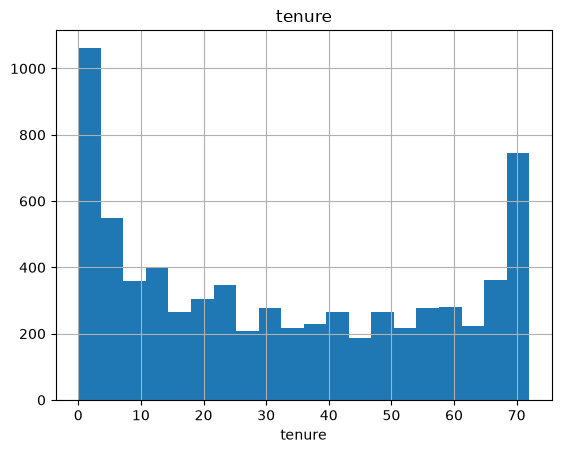

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
10%         2.000000
20%         6.000000
40%        20.000000
50%        29.000000
60%        40.000000
80%        60.000000
90%        69.000000
95%        72.000000
99%        72.000000
max        72.000000
Name: tenure, dtype: float64


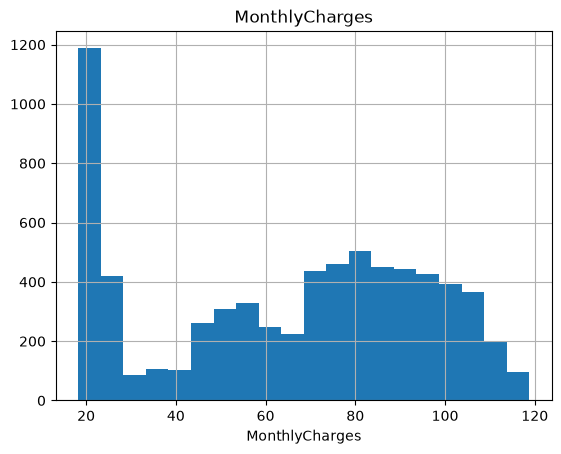

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
10%        20.050000
20%        25.050000
40%        58.830000
50%        70.350000
60%        79.100000
80%        94.250000
90%       102.600000
95%       107.400000
99%       114.729000
max       118.750000
Name: MonthlyCharges, dtype: float64


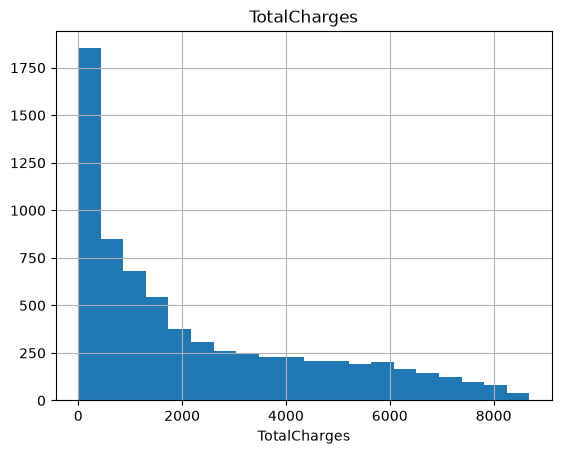

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
10%        83.470000
20%       265.320000
40%       939.780000
50%      1394.550000
60%      2043.710000
80%      4471.440000
90%      5973.690000
95%      6921.025000
99%      8039.256000
max      8684.800000
Name: TotalCharges, dtype: float64


In [12]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.10, 0.20, 0.40, 0.50, 0.60, 0.80, 0.90, 0.95, 0.99]

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)
        print(dataframe[numerical_col].describe(quantiles).T)


for col in num_cols:
    num_summary(df, col, plot=True)

## COMMENTS
Tenure: The distribution shows two peaks, indicating a significant number of new customers (short tenure) and a significant number of long-term customers (long tenure). This bimodal distribution suggests two main customer groups based on their length of time with the company.

Monthly Charges: The distribution is somewhat bimodal; one peak is at the lower end (around $20 USD) and the other is at the higher end (around $80–90 USD). This indicates the existence of different customer groups based on the services to which they subscribe; some prefer basic, lower-cost services, while others opt for more expensive packages.

Total Charges: The distribution is right-skewed, indicating that a large number of customers have relatively low total charges; this is consistent with the significant number of customers having short tenure.

## Categorical Variables

In [13]:
cat_cols

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [14]:
df[cat_cols].describe(include=["object"])

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10756\2976319953.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df[cat_cols].describe(include=["object"])


,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


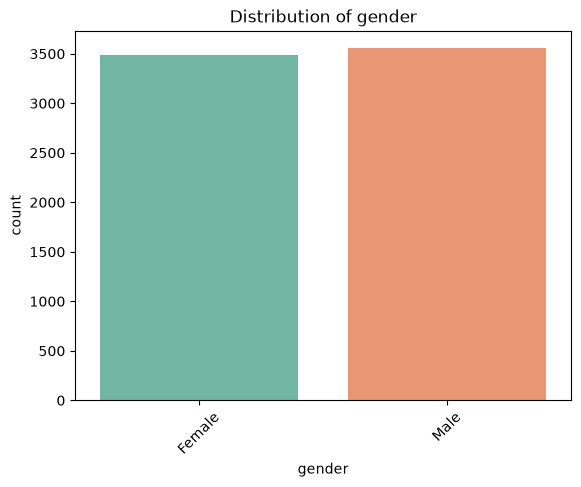

        gender     Ratio
gender                  
Male      3555  50.47565
Female    3488  49.52435
##########################################


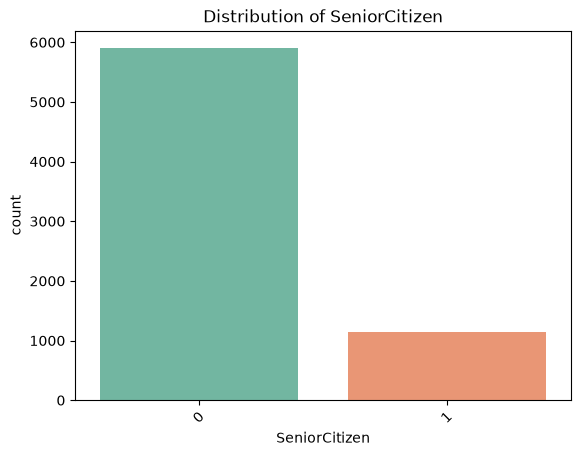

               SeniorCitizen      Ratio
SeniorCitizen                          
0                       5901  83.785319
1                       1142  16.214681
##########################################


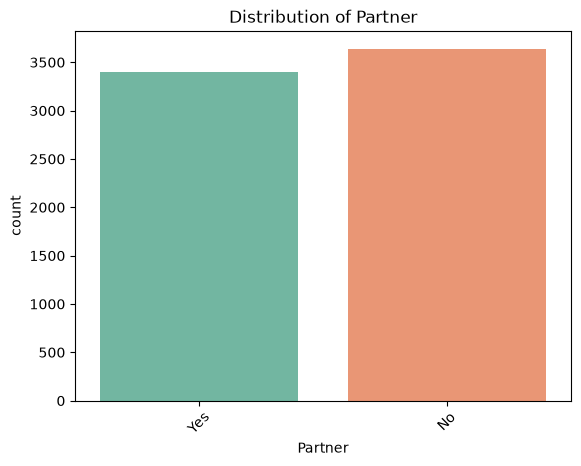

         Partner     Ratio
Partner                   
No          3641  51.69672
Yes         3402  48.30328
##########################################


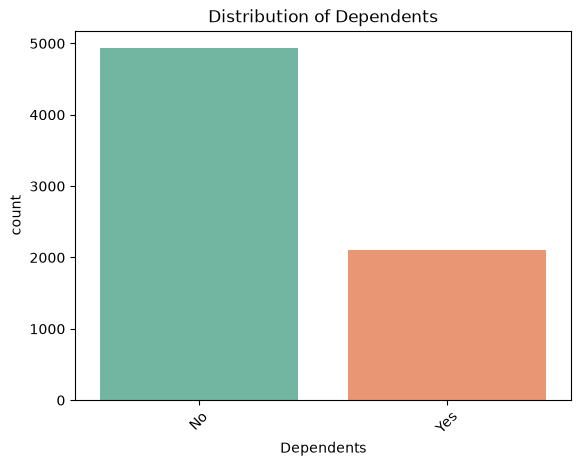

            Dependents      Ratio
Dependents                       
No                4933  70.041176
Yes               2110  29.958824
##########################################


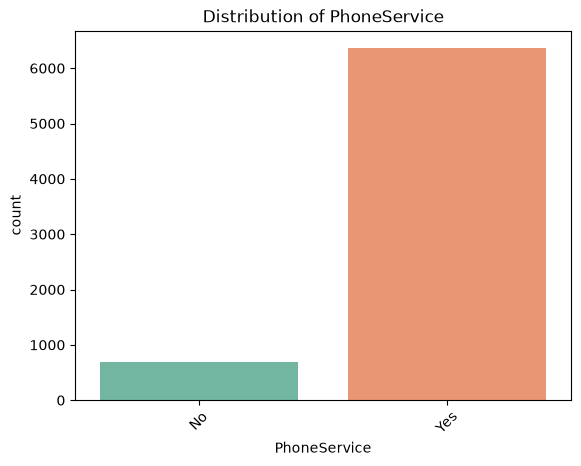

              PhoneService      Ratio
PhoneService                         
Yes                   6361  90.316626
No                     682   9.683374
##########################################


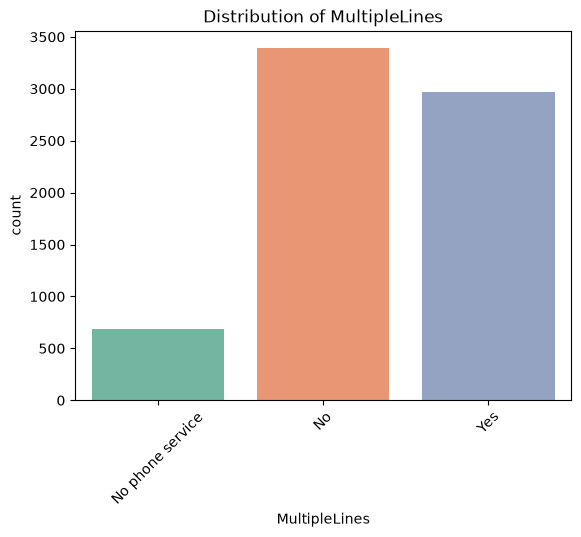

                  MultipleLines      Ratio
MultipleLines                             
No                         3390  48.132898
Yes                        2971  42.183729
No phone service            682   9.683374
##########################################


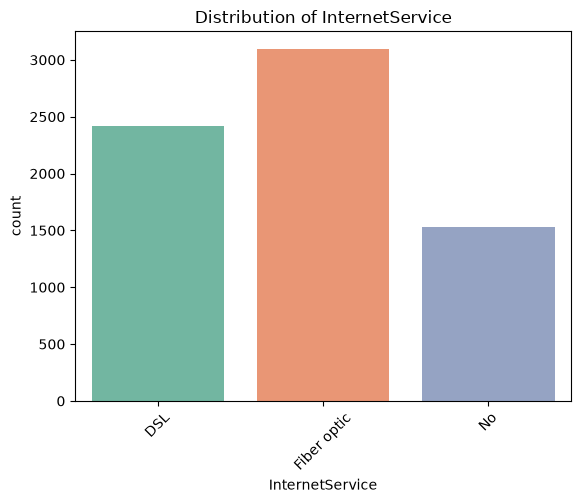

                 InternetService      Ratio
InternetService                            
Fiber optic                 3096  43.958540
DSL                         2421  34.374556
No                          1526  21.666903
##########################################


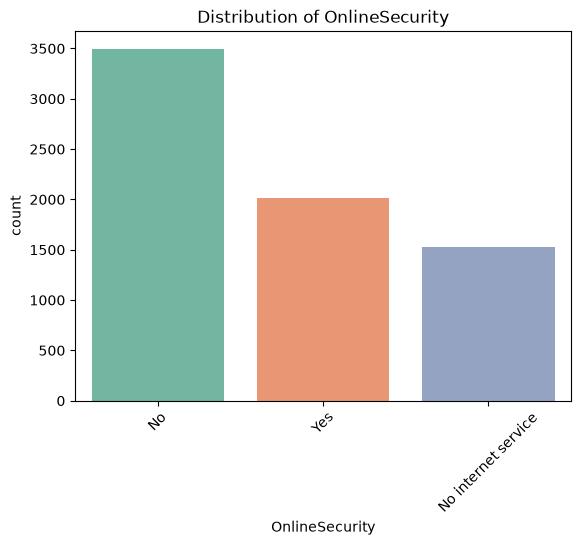

                     OnlineSecurity      Ratio
OnlineSecurity                                
No                             3498  49.666335
Yes                            2019  28.666761
No internet service            1526  21.666903
##########################################


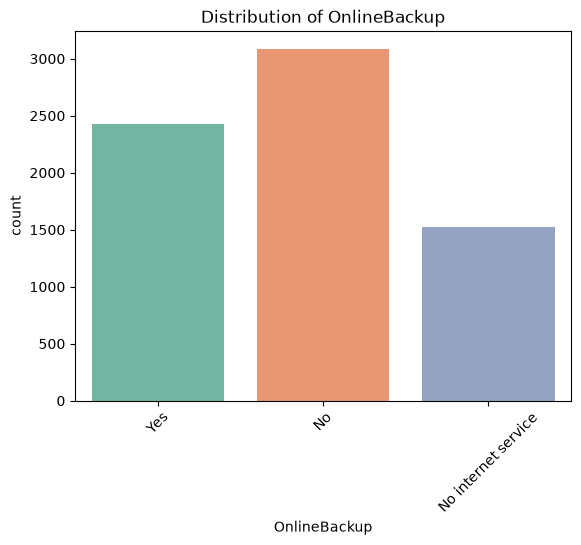

                     OnlineBackup      Ratio
OnlineBackup                                
No                           3088  43.844952
Yes                          2429  34.488144
No internet service          1526  21.666903
##########################################


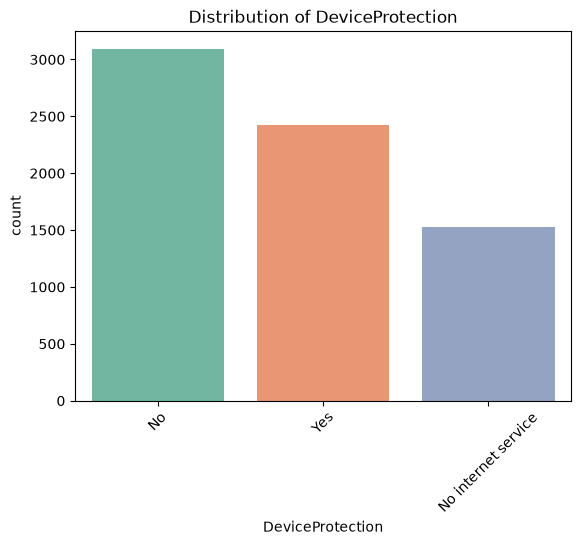

                     DeviceProtection      Ratio
DeviceProtection                                
No                               3095  43.944342
Yes                              2422  34.388755
No internet service              1526  21.666903
##########################################


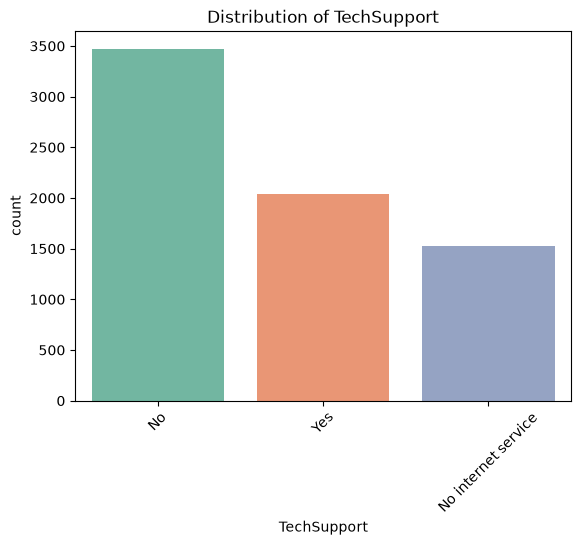

                     TechSupport      Ratio
TechSupport                                
No                          3473  49.311373
Yes                         2044  29.021724
No internet service         1526  21.666903
##########################################


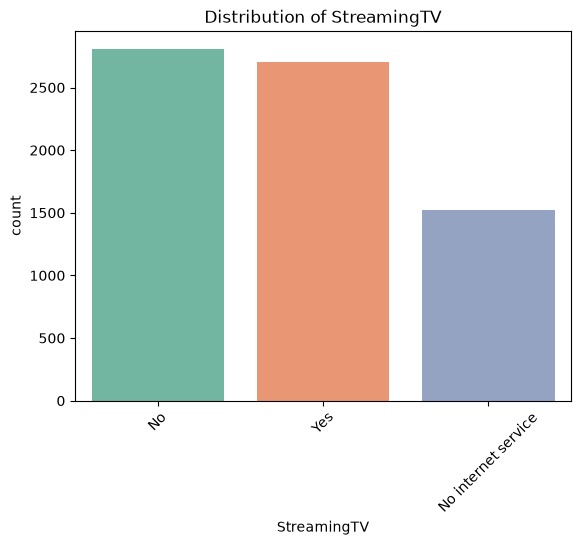

                     StreamingTV      Ratio
StreamingTV                                
No                          2810  39.897771
Yes                         2707  38.435326
No internet service         1526  21.666903
##########################################


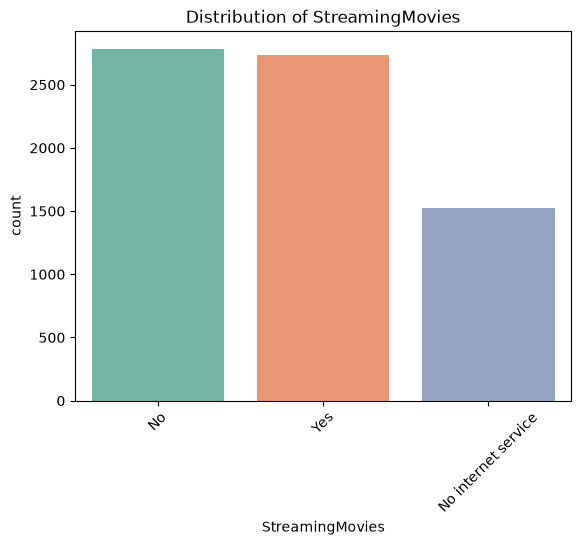

                     StreamingMovies      Ratio
StreamingMovies                                
No                              2785  39.542808
Yes                             2732  38.790288
No internet service             1526  21.666903
##########################################


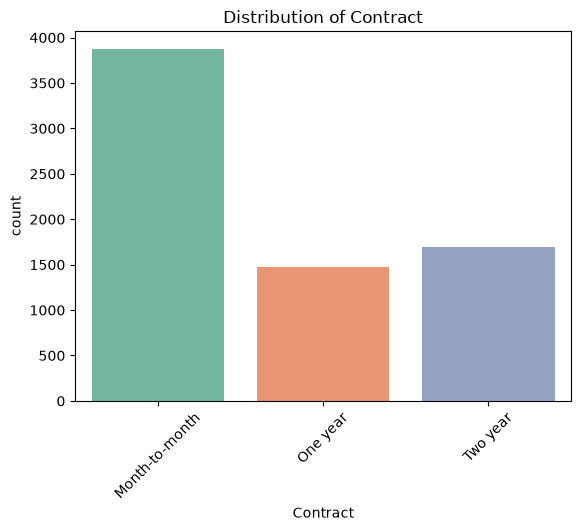

                Contract      Ratio
Contract                           
Month-to-month      3875  55.019168
Two year            1695  24.066449
One year            1473  20.914383
##########################################


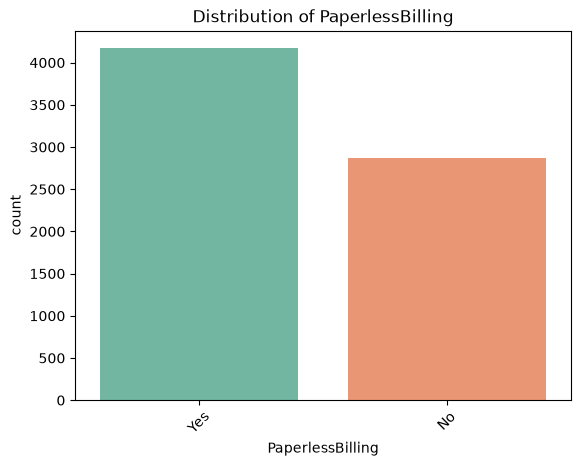

                  PaperlessBilling      Ratio
PaperlessBilling                             
Yes                           4171  59.221922
No                            2872  40.778078
##########################################


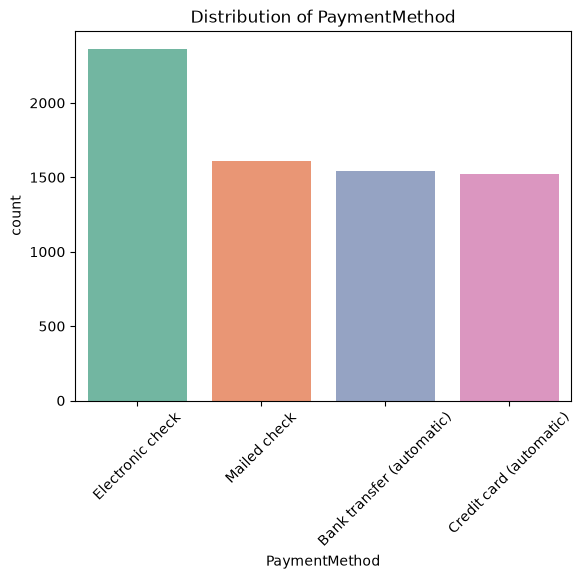

                           PaymentMethod      Ratio
PaymentMethod                                      
Electronic check                    2365  33.579441
Mailed check                        1612  22.887974
Bank transfer (automatic)           1544  21.922476
Credit card (automatic)             1522  21.610109
##########################################


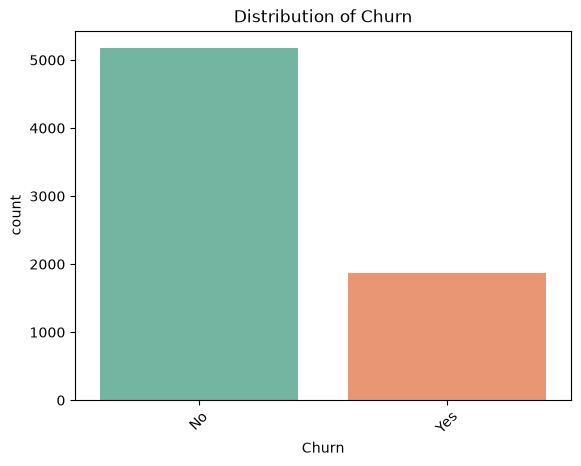

       Churn      Ratio
Churn                  
No      5174  73.463013
Yes     1869  26.536987
##########################################


In [15]:
def cat_summary(dataframe, col_name, plot=False):
    
    if plot:
        sns.countplot(
            x=col_name,
            data=dataframe,
            hue=col_name,
            palette="Set2",
            legend=False
        )

        plt.xticks(rotation=45)
        plt.title(f"Distribution of {col_name}")
        plt.show()

    print(pd.DataFrame({
        col_name: dataframe[col_name].value_counts(),
        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)
    }))

    print("##########################################")


for col in cat_cols:
    cat_summary(df, col, plot=True)

## Conclusion

Gender: The number of male and female customers is roughly equal.

Partners and Dependents: A slightly larger number of customers do not have partners or dependents.

PhoneService: Most customers (approximately 90%) have phone service.

MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies: These columns contain various categories, and the majority of customers do not have additional services such as online security, technical support, etc.

Contract: The most common contract type is month-to-month.

PaperlessBilling: The majority of customers (approximately 59%) use paperless billing.

PaymentMethod: The most common payment method is electronic check.

Churn: As indicated by the frequency of 'No' in the churn column, the churn rate is lower than the retention rate.

## Churn Analysis

In [16]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [17]:
df["Churn"] = df["Churn"].map({'No':0,'Yes':1})

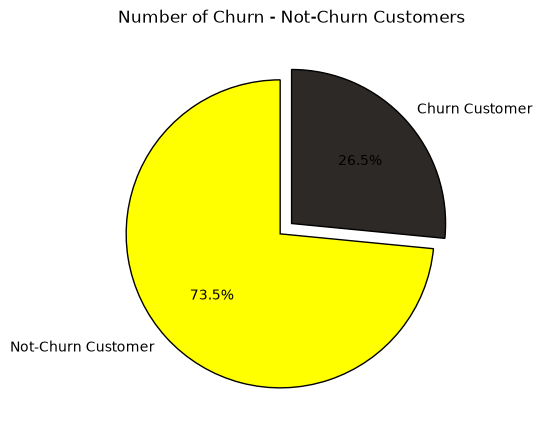

In [18]:
colors = ['#FFFF00','#2D2926']
l = list(df['Churn'].value_counts())
circle = [l[0] / sum(l) * 100,l[1] / sum(l) * 100]

fig = plt.subplots(figsize = (20,5))
plt.pie(circle,labels = ['Not-Churn Customer','Churn Customer'],autopct = '%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Churn - Not-Churn %');

plt.title('Number of Churn - Not-Churn Customers');
plt.show()

The dataset is unbalanced, with a ratio of nearly 3:1 for Not-Churn: Churn customers!

Due to this, predictions will be biased towards Not-Churn customers.

Visualizations will also display this bias!

The Customer Churn Distribution graph and the calculated churn rate provide the following information:

Approximately 73.46% of customers did not churn, indicating that the majority are stable customers.

Approximately 26.54% of customers churned; this is a significant rate and can be a cause for concern for the business.

This churn rate highlights the importance of understanding the factors contributing to customer churn. Businesses can use this information to develop strategies to improve customer retention.

## Categorical Variables vs Target Variable (Churn):

Next, let's analyze the distribution of some key categorical variables, especially those that might have a significant impact on churn, like Contract, InternetService, and PaymentMethod.

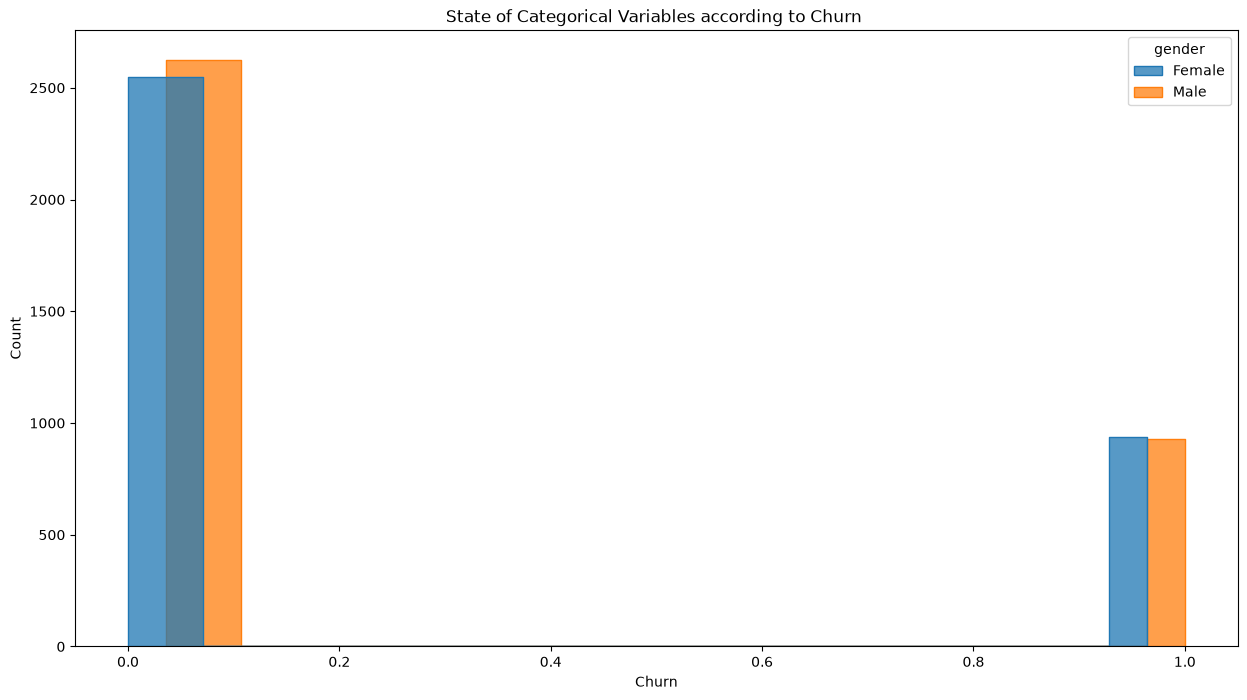

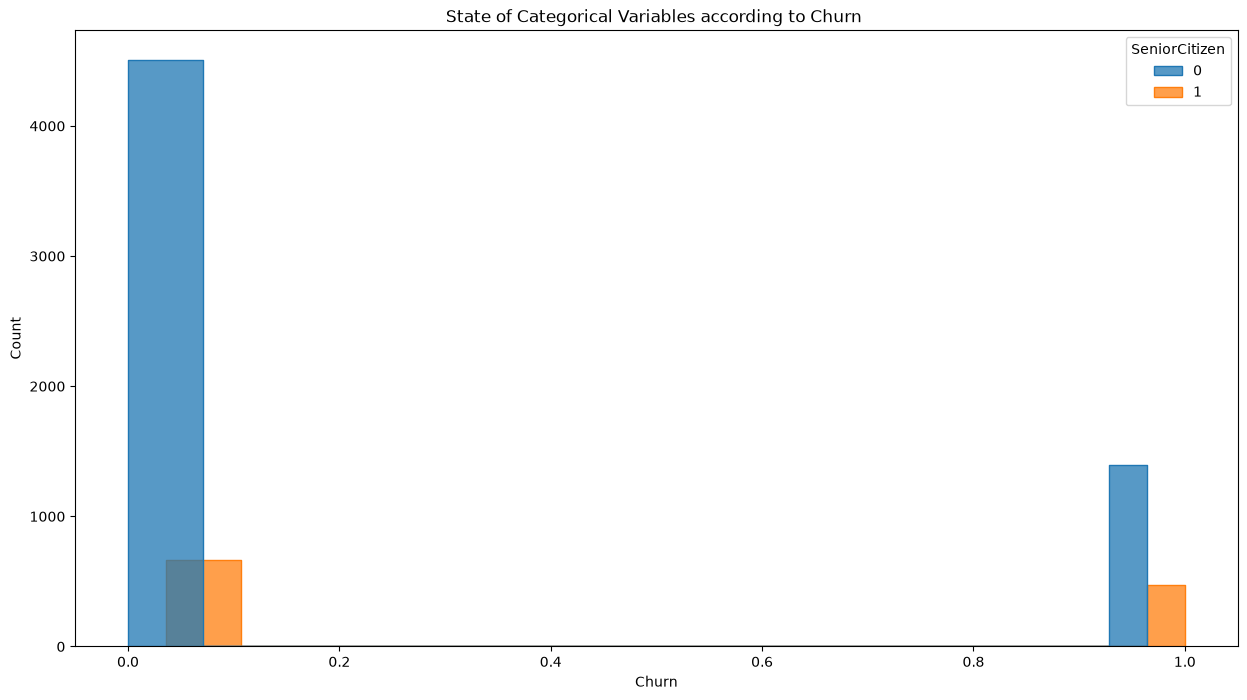

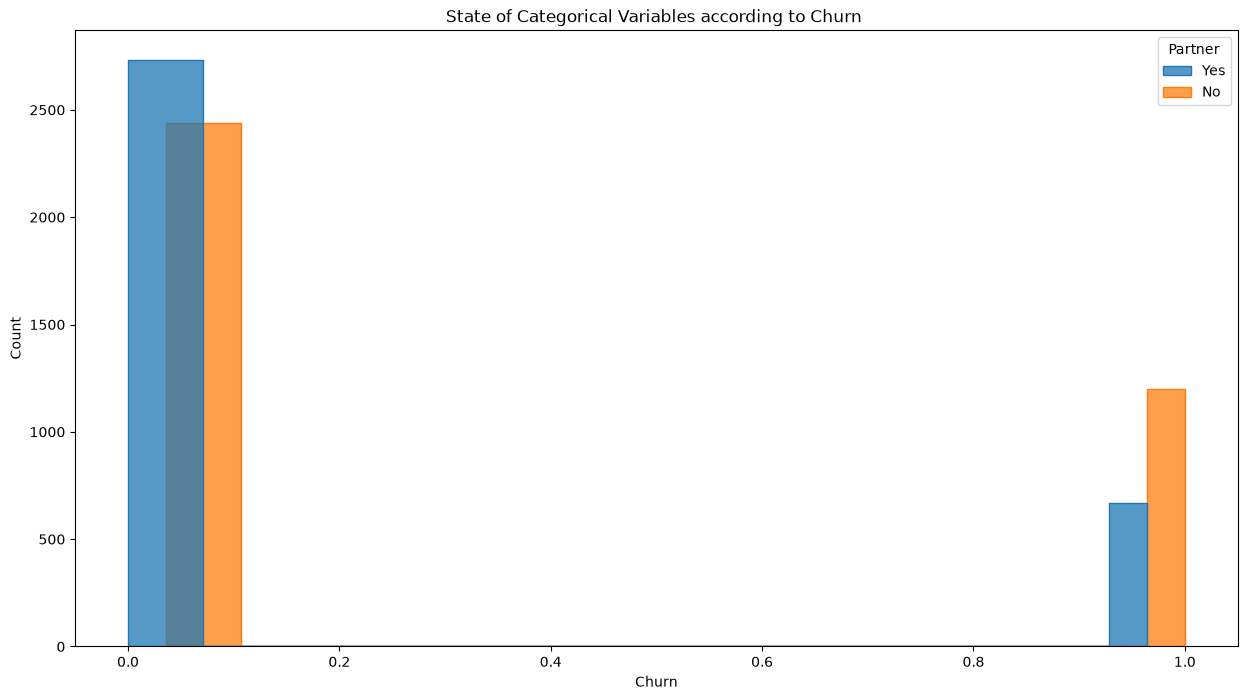

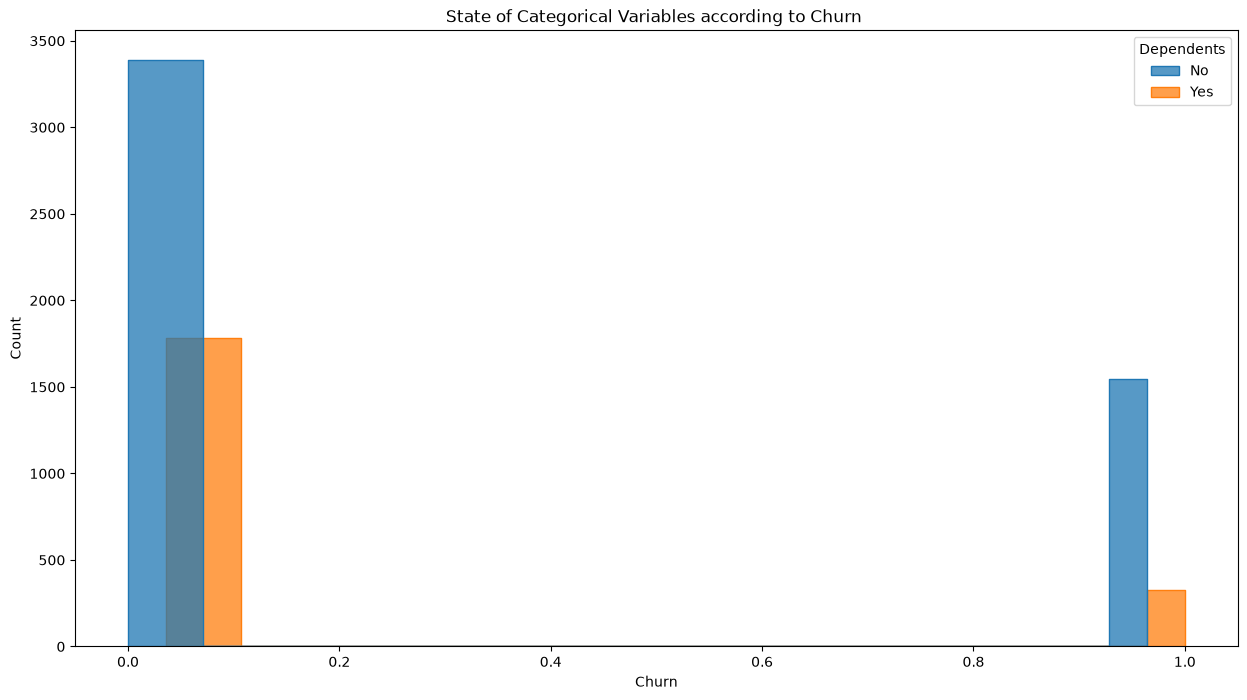

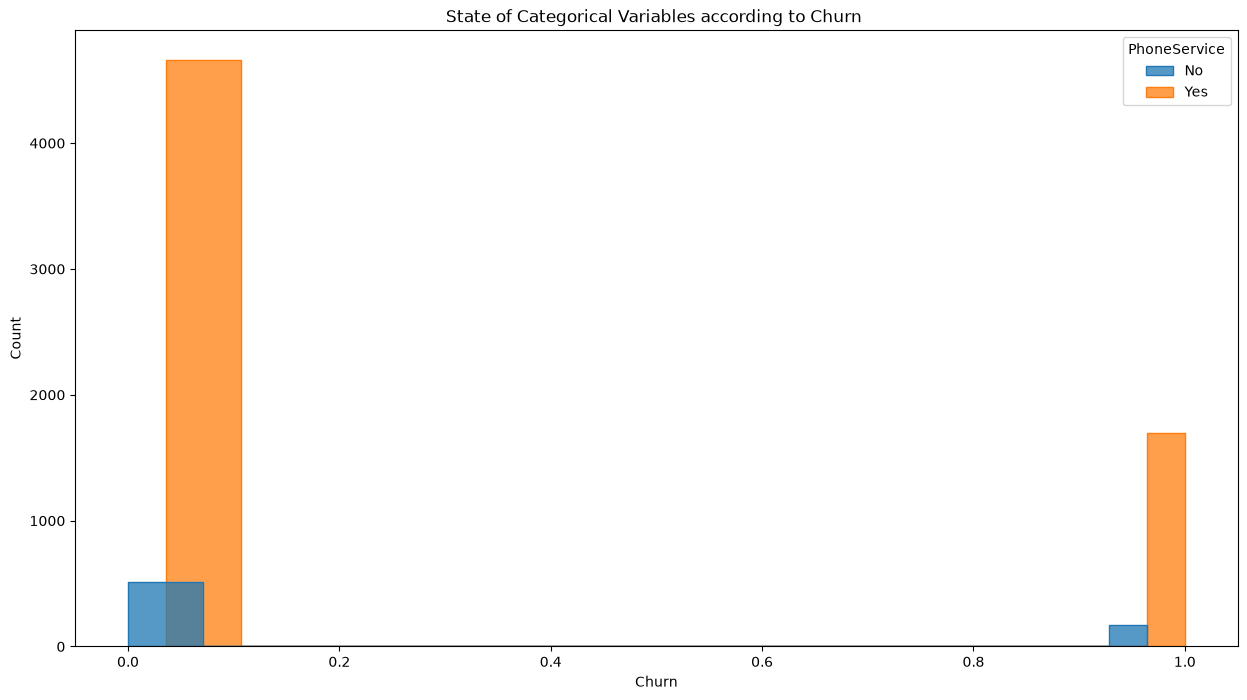

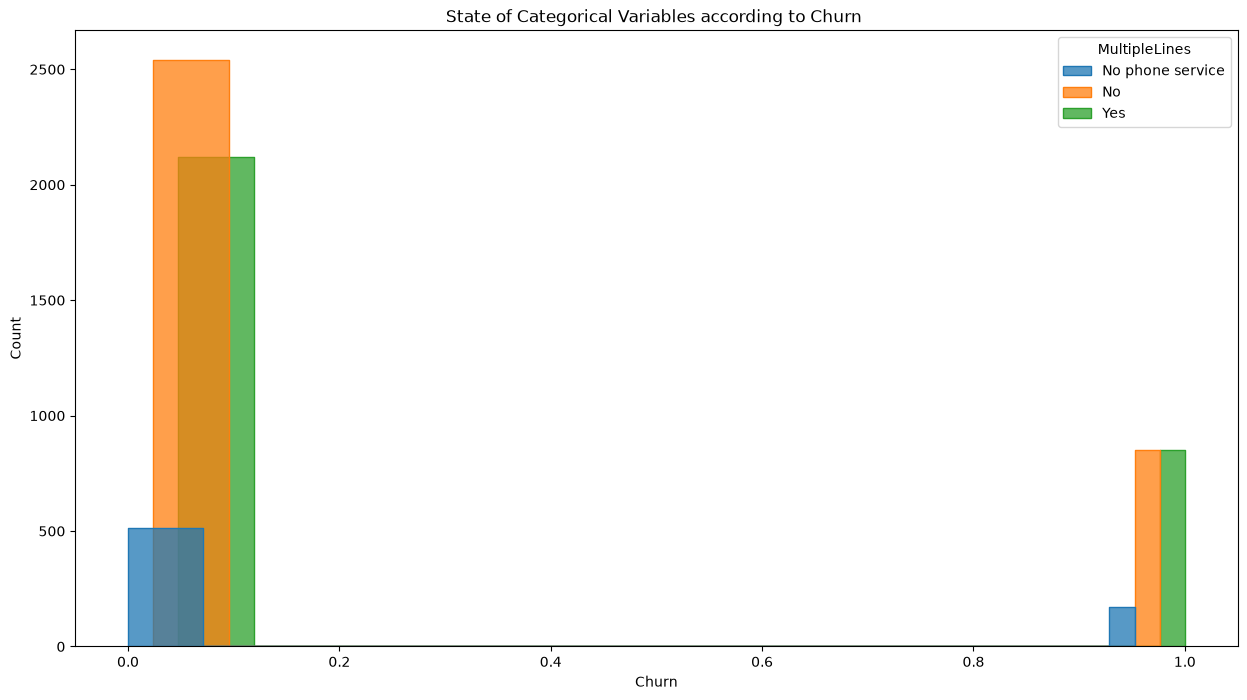

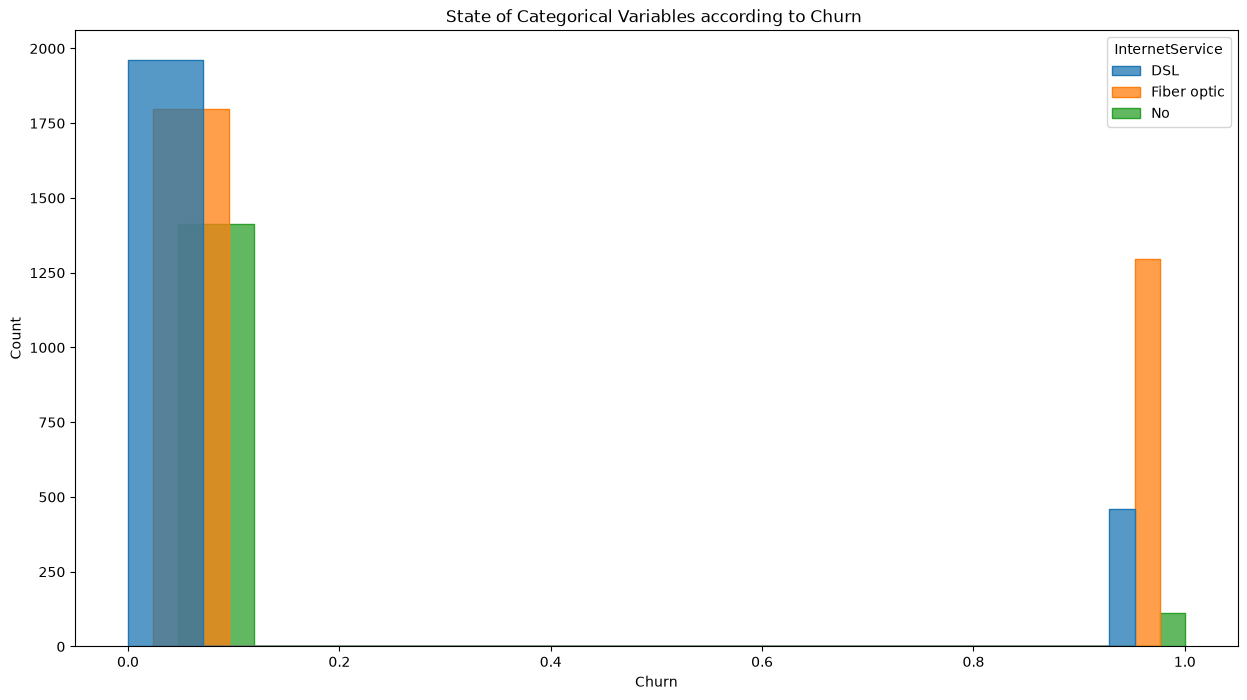

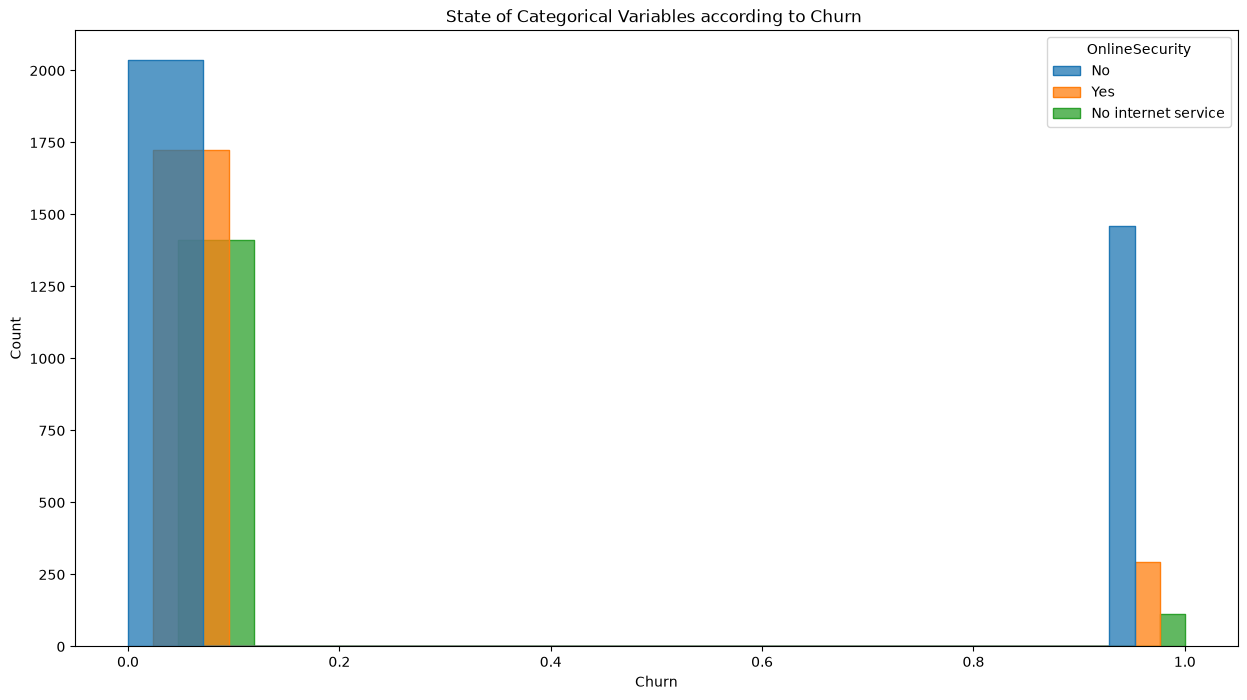

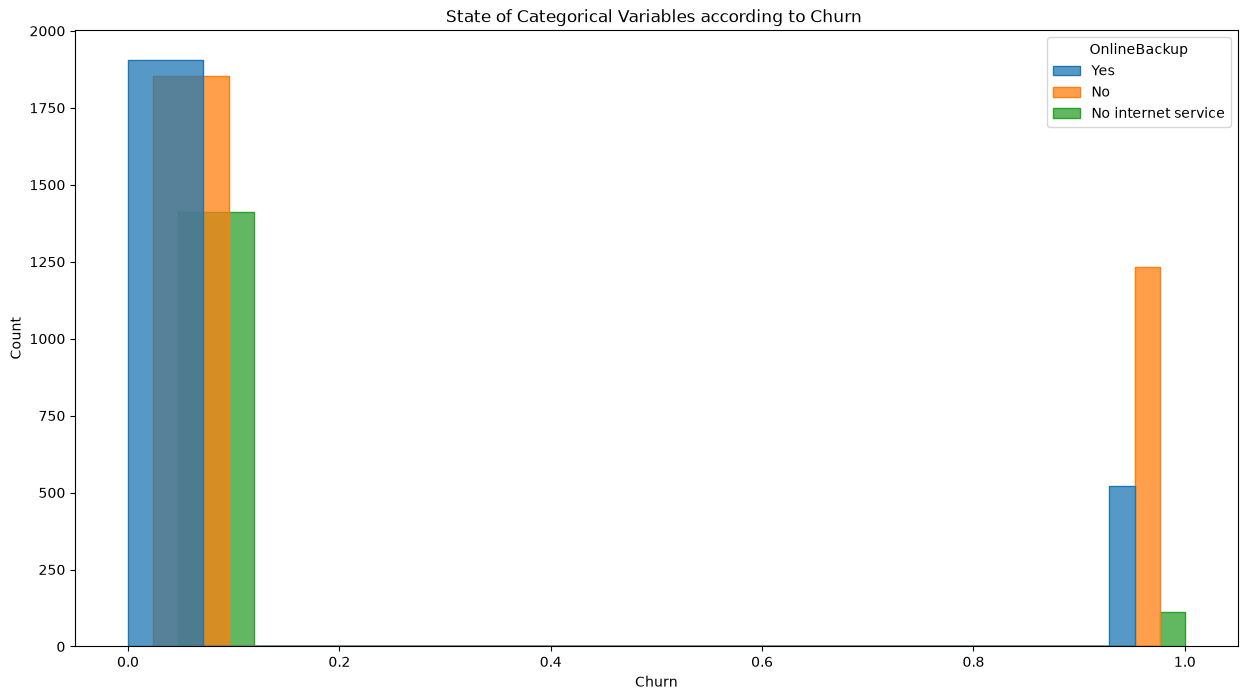

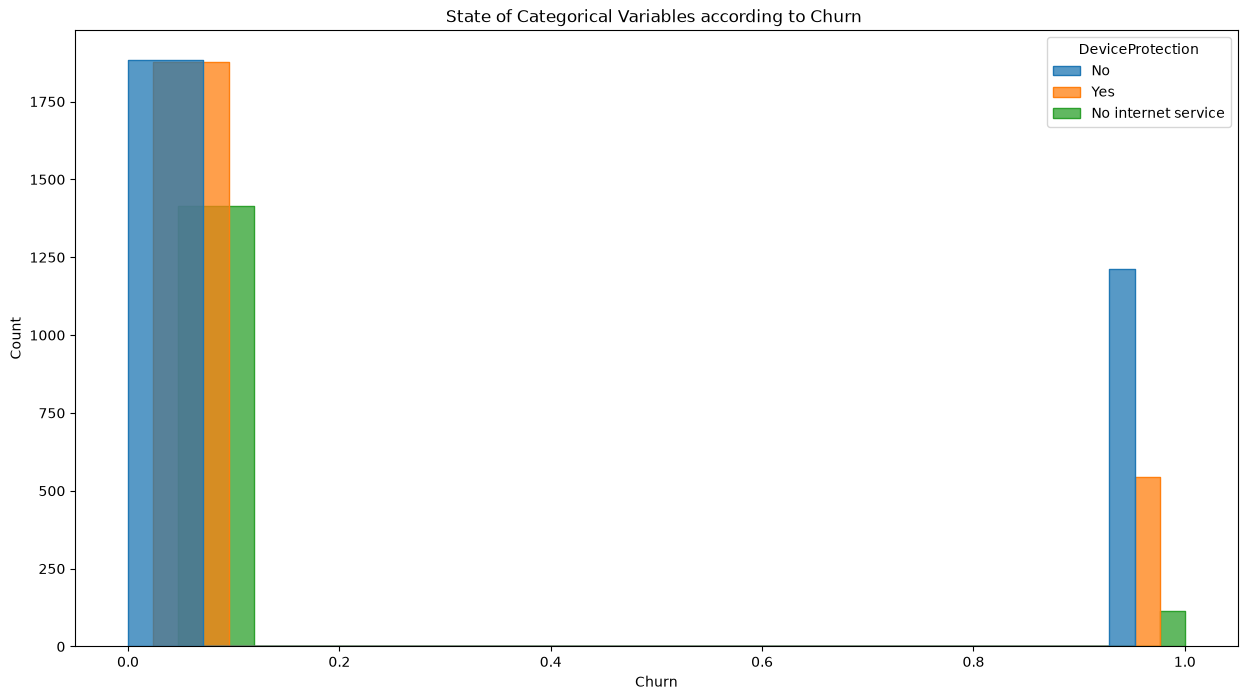

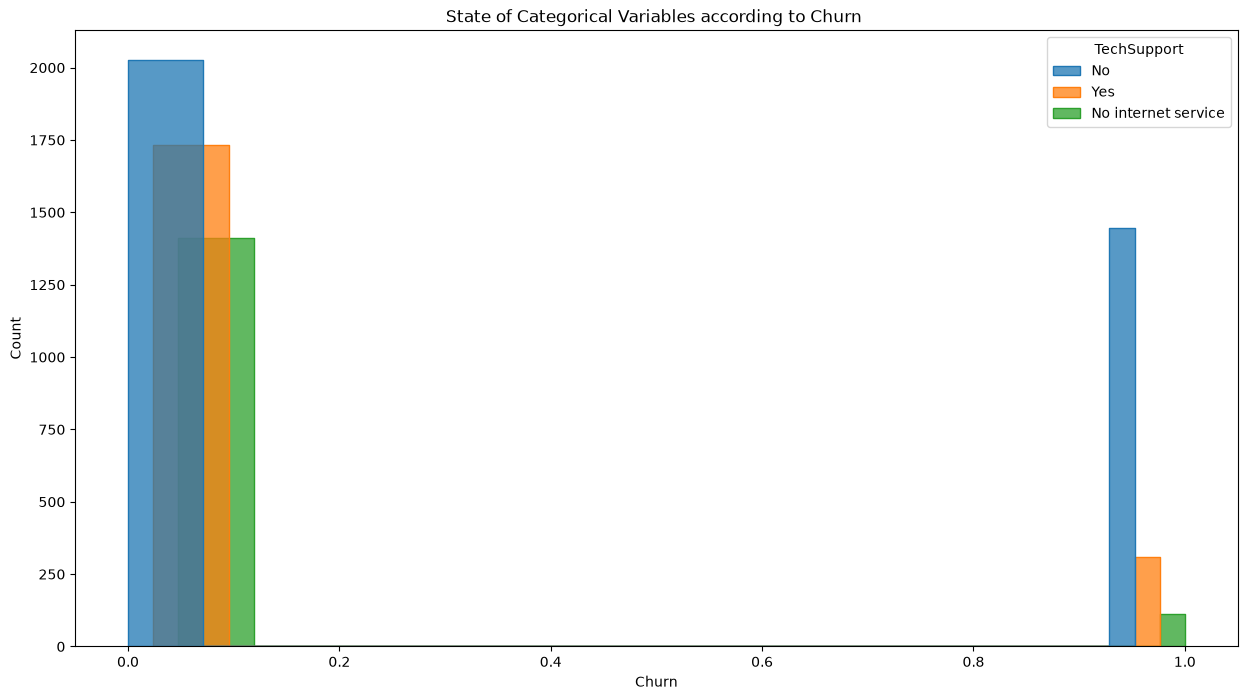

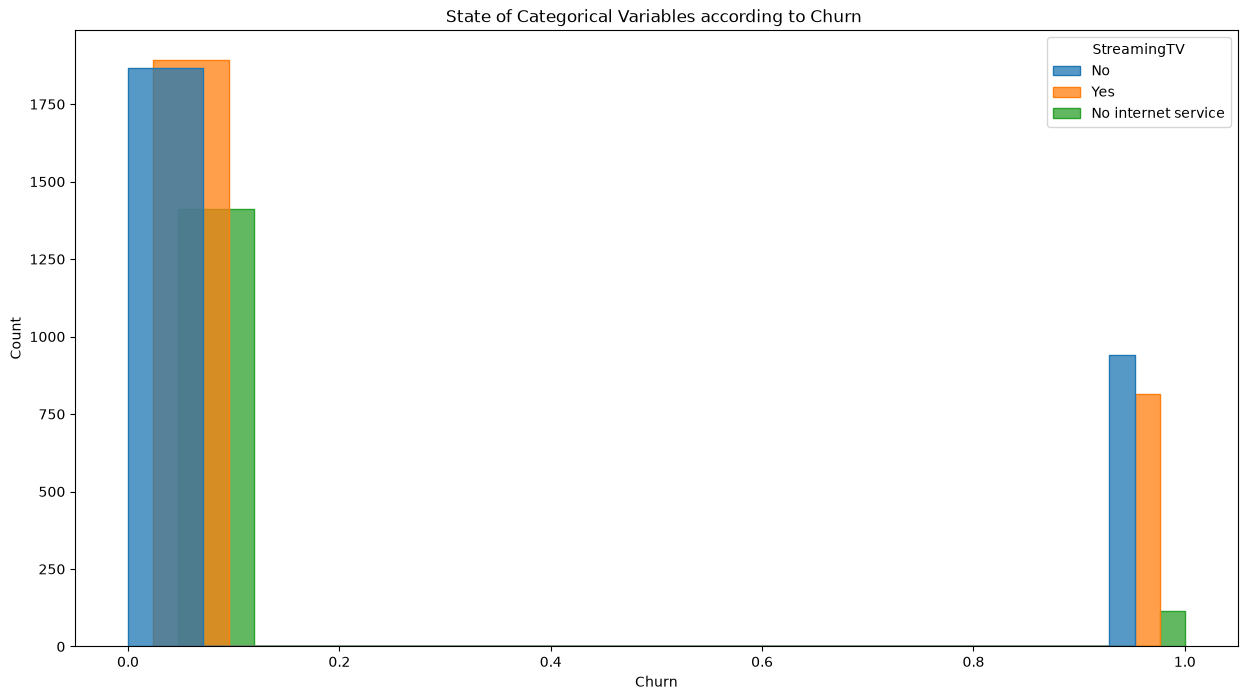

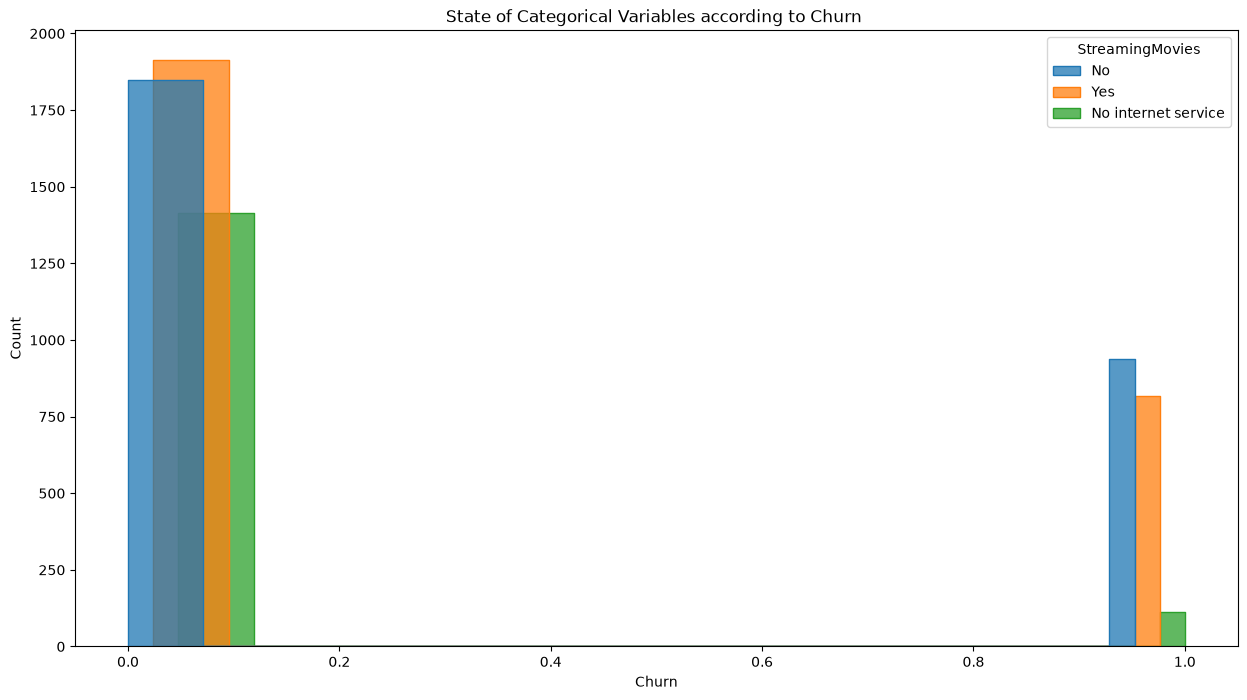

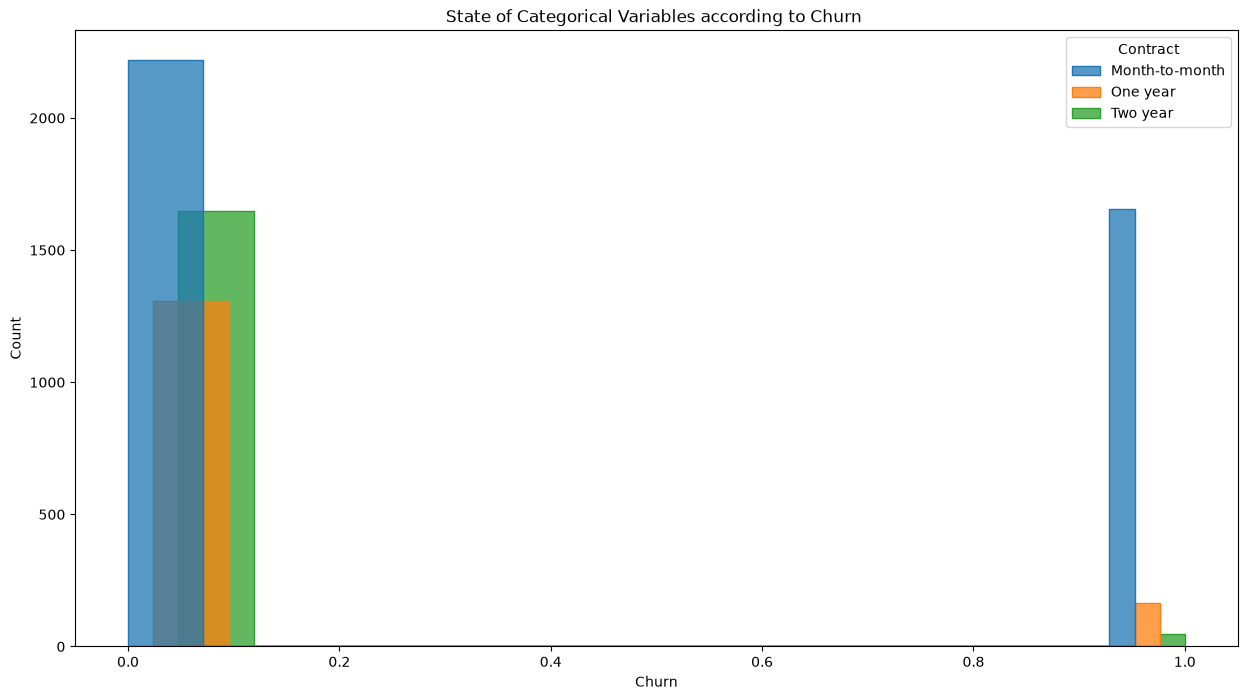

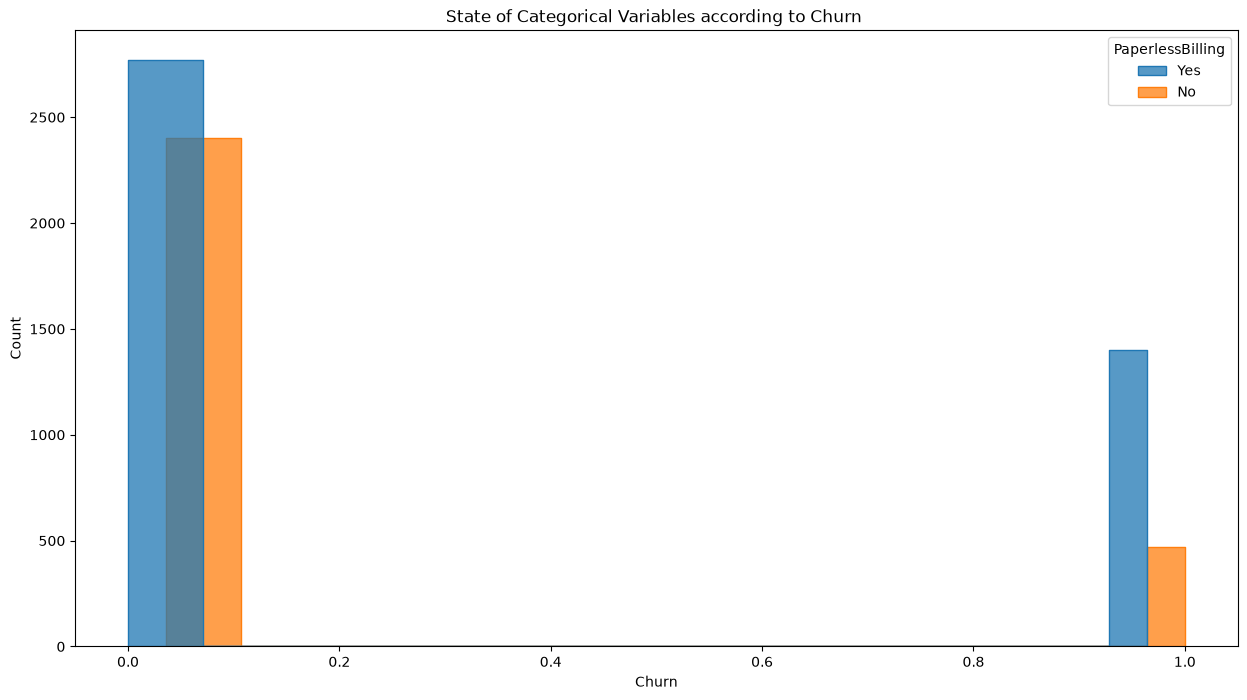

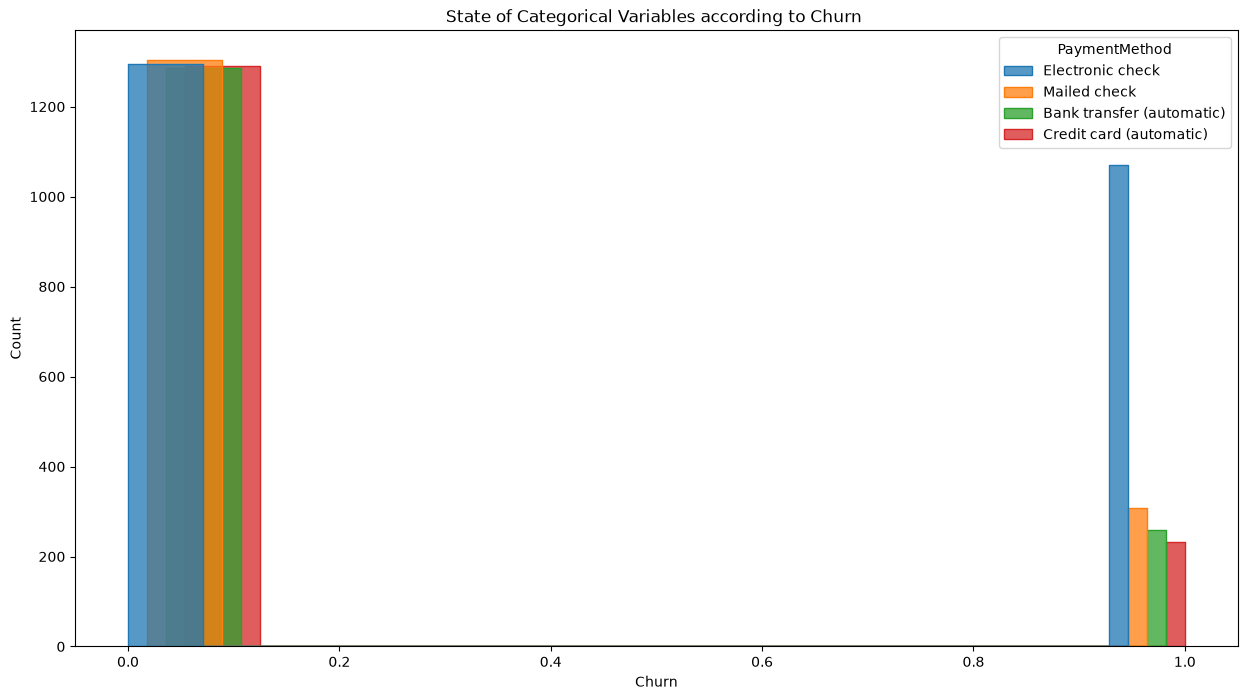

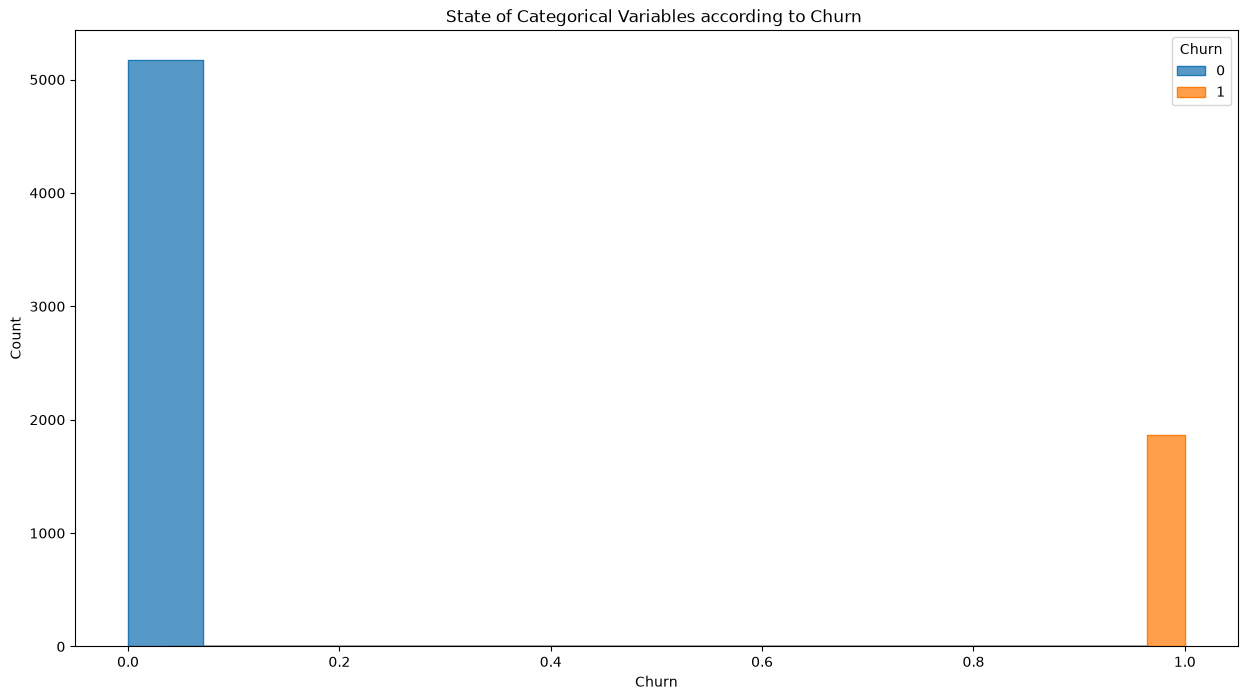

In [19]:
def target_vs_category_visual(dataframe,target, categorical_col):
    plt.figure(figsize=(15,8))
    sns.histplot(x=target,hue=categorical_col, data=dataframe,element="step",multiple="dodge")
    plt.title("State of Categorical Variables according to Churn ")
    plt.show()
    
def target_summary_with_cat(dataframe,target,categorical_col):
    print(pd.DataFrame({"CHURN_MEAN": dataframe.groupby(categorical_col)[target].mean()}))
    print(20*"-")


for col in cat_cols:
    target_vs_category_visual(df,"Churn",col)

## Customer Churn Analysis & Comments

Customer churn rates for male and female customers are very similar!

Likewise, the number of SeniorCitizen customers is quite low! Furthermore, we observe a churn rate of nearly 40% among SeniorCitizen customers; this corresponds to a total of 476 out of 1,142 SeniorCitizen customers.

Customers living with a partner experienced lower churn rates compared to those who do not live with a partner.

Similarly, the churn rate is high for customers who do not have dependents!

Regarding telephone service, a higher number of customers were retained compared to those who discontinued the service (even though the service itself was not present).

In the case of multiple lines, the churn rate remains the same regardless of whether multiple lines are present or not.

Many customers showed resistance to the use of fiber-optic cables for internet service provision. Conversely, the graph above indicates that customers prefer using DSL for their internet services!

Streaming TV and Streaming Movies show the same pattern; many customers were lost regardless of whether or not they subscribed to these services.

When it comes to customer services, OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport are crucial—as highlighted in the visualizations above!

A significant number of customers have switched service providers due to inadequacies in the aforementioned service features.

Customer churn is notably high among those on month-to-month contracts. This is likely because customers test the various services offered to them—often opting for a one-month trial to save money!

Another factor could be inconsistency in the overall experience regarding internet, streaming, and telephone services. Every customer has different priorities; consequently, if even one of these three services falls short, the customer may cancel the entire package!

Data regarding Paperless Billing reveals a high rate of customer attrition, likely due to payment or receipt-related issues.

Customers have shown clear dissatisfaction with the electronic check payment method. Strikingly, out of 2,365 bills paid via electronic check, 1,071 customers churned. The company definitely needs to either

discontinue the electronic check method or make it seamless and user-friendly.

## Categorical Variables for Churn mean

In [20]:
for col in cat_cols:
    target_summary_with_cat(df,"Churn",col)

        CHURN_MEAN
gender            
Female    0.269209
Male      0.261603
--------------------
               CHURN_MEAN
SeniorCitizen            
0                0.236062
1                0.416813
--------------------
         CHURN_MEAN
Partner            
No         0.329580
Yes        0.196649
--------------------
            CHURN_MEAN
Dependents            
No            0.312791
Yes           0.154502
--------------------
              CHURN_MEAN
PhoneService            
No              0.249267
Yes             0.267096
--------------------
                  CHURN_MEAN
MultipleLines               
No                  0.250442
No phone service    0.249267
Yes                 0.286099
--------------------
                 CHURN_MEAN
InternetService            
DSL                0.189591
Fiber optic        0.418928
No                 0.074050
--------------------
                     CHURN_MEAN
OnlineSecurity                 
No                     0.417667
No internet service 

## Group 1 : Customer Information :
gender | SeniorCitizen | Partner | Dependents

In [21]:
# Female / Male based on position
gender = df[df['Churn'] == 1]['gender'].value_counts()
gender_pct = [gender.iloc[0] / gender.sum() * 100, gender.iloc[1] / gender.sum() * 100]

# SeniorCitizen based on position
seniorcitizen = df[df['Churn'] == 1]['SeniorCitizen'].value_counts()
seniorcitizen_pct = [seniorcitizen.iloc[0] / seniorcitizen.sum() * 100, seniorcitizen.iloc[1] / seniorcitizen.sum() * 100]

# Partner (No - Yes)
partner = df[df['Churn'] == 1]['Partner'].value_counts()
partner_pct = [partner.iloc[0] / partner.sum() * 100, partner.iloc[1] / partner.sum() * 100]

# Dependents (No - Yes)
dependents = df[df['Churn'] == 1]['Dependents'].value_counts()
dependents_pct = [dependents.iloc[0] / dependents.sum() * 100, dependents.iloc[1] / dependents.sum() * 100]

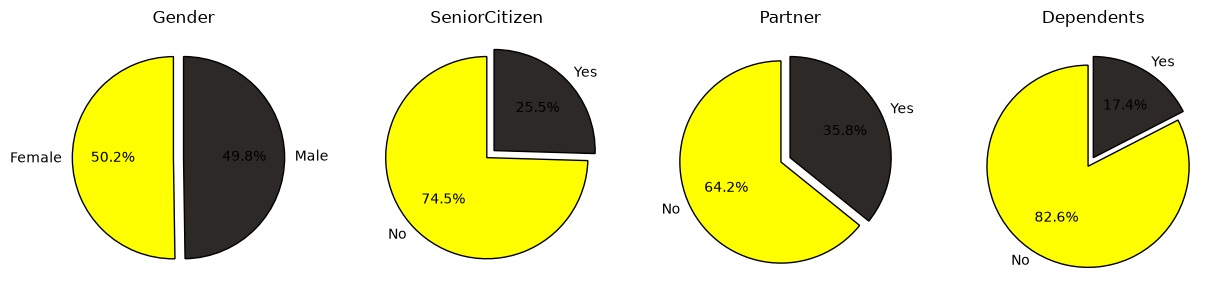

In [22]:
ax,fig = plt.subplots(nrows = 1,ncols = 4,figsize = (15,15))

plt.subplot(1,4,1)
plt.pie(gender,labels = ['Female','Male'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Gender');

plt.subplot(1,4,2)
plt.pie(seniorcitizen,labels = ['No', 'Yes'],autopct='%1.1f%%',startangle = 90,explode = (0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('SeniorCitizen');

plt.subplot(1,4,3)
plt.pie(partner,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Partner');

plt.subplot(1,4,4)
plt.pie(dependents,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Dependents');

## Commentary
We observe an even 50-50 split between male and female customers who have discontinued the service. This suggests that the reason for the churn is linked to the service itself or a specific process that elicited a negative reaction from customers!

75% of the customers who left are not senior citizens! This is a crucial insight that warrants the company's attention!

Customers living alone have cancelled the service. Data regarding partners and dependents reveals that, on average, 73.4% of the customers who churned lived alone.

## Group 2: Services Subscribed by the Customer :¶
PhoneService | MultipleLines | InternetService | StreamingTV | StreamingMovies |¶

In [23]:
phoneservice = (
    df.loc[df["Churn"] == 1, "PhoneService"]
      .value_counts(normalize=True)
      .mul(100)
      .reindex(["No", "Yes"], fill_value=0)
      .tolist()
)

multiplelines = (
    df.loc[df["Churn"] == 1, "MultipleLines"]
      .value_counts(normalize=True)
      .mul(100)
      .reindex(["No", "No phone service", "Yes"], fill_value=0)
      .tolist()
)

internetservice = (
    df.loc[df["Churn"] == 1, "InternetService"]
      .value_counts(normalize=True)
      .mul(100)
      .reindex(["DSL", "Fiber optic", "No"], fill_value=0)
      .tolist()
)

streamingtv = (
    df.loc[df["Churn"] == 1, "StreamingTV"]
      .value_counts(normalize=True)
      .mul(100)
      .reindex(["No", "No internet service", "Yes"], fill_value=0)
      .tolist()
)

streamingmovies = (
    df.loc[df["Churn"] == 1, "StreamingMovies"]
      .value_counts(normalize=True)
      .mul(100)
      .reindex(["No", "No internet service", "Yes"], fill_value=0)
      .tolist()
)

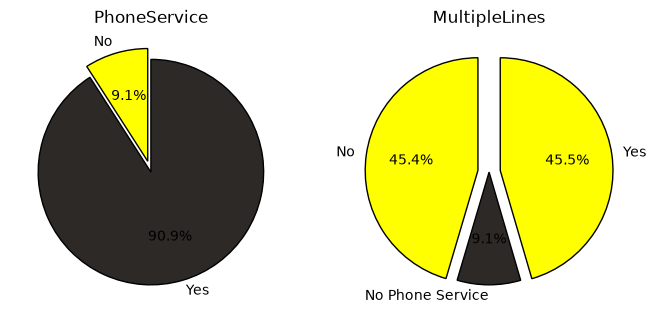

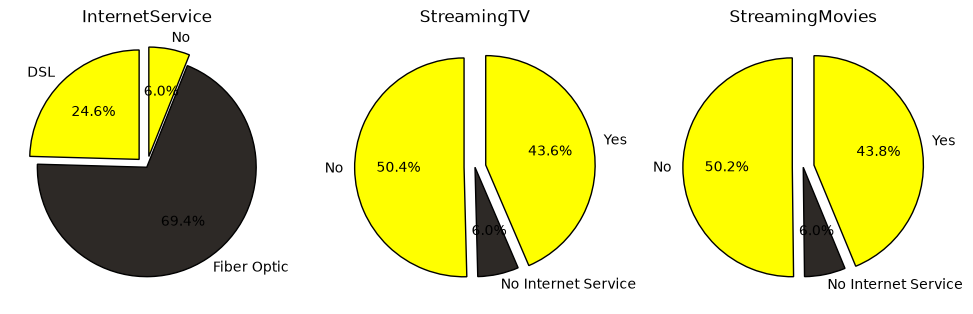

In [24]:
ax,fig = plt.subplots(nrows = 1,ncols = 2,figsize = (8,8))

plt.subplot(1,2,1)
plt.pie(phoneservice,labels = ['No', 'Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('PhoneService');

plt.subplot(1,2,2)
plt.pie(multiplelines,labels = ['No','No Phone Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('MultipleLines');

ax,fig = plt.subplots(nrows = 1,ncols = 3,figsize = (12,12))

plt.subplot(1,3,1)
plt.pie(internetservice,labels = ['DSL', 'Fiber Optic','No'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('InternetService');

plt.subplot(1,3,2)
plt.pie(streamingtv,labels = ['No', 'No Internet Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('StreamingTV');

plt.subplot(1,3,3)
plt.pie(streamingmovies,labels = ['No', 'No Internet Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('StreamingMovies');


Despite the provision of phone service, a large percentage of customers switched their phone service!

Similarly, the availability of MultipleLines did not matter, as customer cancellations occurred regardless!

Customers certainly did not appreciate the approach of providing Internet service via fiber-optic cables, resulting in a definitive 70% churn rate!

Customers who did not have StreamingTV and StreamingMovies services definitely cancelled their subscriptions; however, an average of 43.7% of customers switched their subscriptions even though they consumed streaming content.

## Group 2: Services Subscribed by the Customer
OnlineSecurity | OnlineBackup | DeviceProtection | TechSupport

In [25]:
onlinesecurity = (
    df.loc[df["Churn"] == 1, "OnlineSecurity"]
      .value_counts(normalize=True)
      .mul(100)
      .reindex(["No", "No internet service", "Yes"], fill_value=0)
      .tolist()
)

onlinebackup = (
    df.loc[df["Churn"] == 1, "OnlineBackup"]
      .value_counts(normalize=True)
      .mul(100)
      .reindex(["No", "No internet service", "Yes"], fill_value=0)
      .tolist()
)

deviceprotection = (
    df.loc[df["Churn"] == 1, "DeviceProtection"]
      .value_counts(normalize=True)
      .mul(100)
      .reindex(["No", "No internet service", "Yes"], fill_value=0)
      .tolist()
)

techsupport = (
    df.loc[df["Churn"] == 1, "TechSupport"]
      .value_counts(normalize=True)
      .mul(100)
      .reindex(["No", "No internet service", "Yes"], fill_value=0)
      .tolist()
)

Text(0.5, 1.0, 'TechSupport')

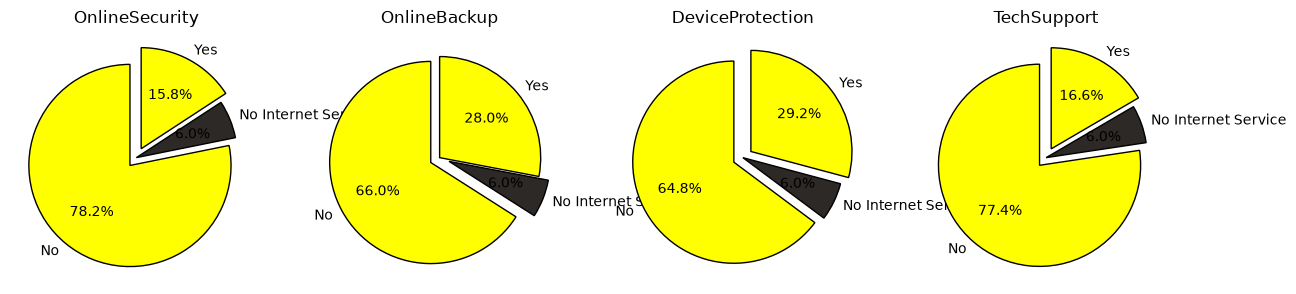

In [26]:
ax,fig = plt.subplots(nrows = 1,ncols = 4,figsize = (15,15))

plt.subplot(1,4,1)
plt.pie(onlinesecurity,labels = ['No', 'No Internet Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('OnlineSecurity');

plt.subplot(1,4,2)
plt.pie(onlinebackup,labels = ['No', 'No Internet Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('OnlineBackup');

plt.subplot(1,4,3)
plt.pie(deviceprotection,labels = ['No', 'No Internet Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('DeviceProtection');

plt.subplot(1,4,4)
plt.pie(techsupport,labels = ['No', 'No Internet Service','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('TechSupport')

The pie charts above highlight the importance of providing OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport, as an average of 71.6% of customers discontinue their services due to the lack of these features!


## Group 3 : Contract | PaperlessBilling | PaymentMethod |


In [27]:
# Contract (Month-to-month, One year, Two year)
contract = df[df['Churn'] == 1]['Contract'].value_counts()
contract_pct = [
    contract.iloc[0] / contract.sum() * 100, 
    contract.iloc[1] / contract.sum() * 100, 
    contract.iloc[2] / contract.sum() * 100
]

# Paperless Billing (No, Yes)
paperlessbilling = df[df['Churn'] == 1]['PaperlessBilling'].value_counts()
paperlessbilling_pct = [
    paperlessbilling.iloc[0] / paperlessbilling.sum() * 100,
    paperlessbilling.iloc[1] / paperlessbilling.sum() * 100
]

# Payment Method
paymentmethod = df[df['Churn'] == 1]['PaymentMethod'].value_counts()
paymentmethod_pct = [
    paymentmethod.iloc[0] / paymentmethod.sum() * 100, 
    paymentmethod.iloc[1] / paymentmethod.sum() * 100, 
    paymentmethod.iloc[2] / paymentmethod.sum() * 100, 
    paymentmethod.iloc[3] / paymentmethod.sum() * 100
]

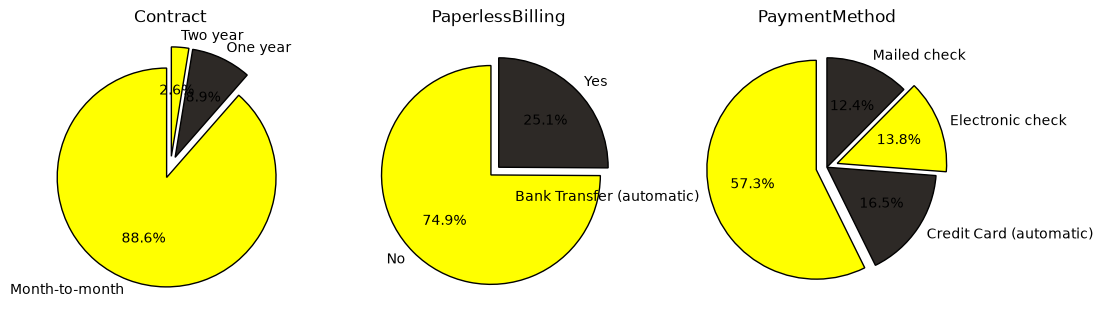

In [28]:
ax,fig = plt.subplots(nrows = 1,ncols = 3,figsize = (12,12))

plt.subplot(1,3,1)
plt.pie(contract,labels = ['Month-to-month','One year','Two year'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0.1,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Contract');

plt.subplot(1,3,2)
plt.pie(paperlessbilling,labels = ['No', 'Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('PaperlessBilling');

plt.subplot(1,3,3)
plt.pie(paymentmethod,labels = ['Bank Transfer (automatic)','Credit Card (automatic)','Electronic check','Mailed check'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('PaymentMethod');

## Comment
Month-to-month contracts account for the dominant share of the massive 88.6% customer churn!

Paperless billing does not seem to be popular with customers!

Electronic checks must definitely be eliminated, as they account for 57.3% of the churn. This is followed by checks by mail, bank transfers (automatic), and credit cards (automatic)!

## Numerical Variables vs Target Variable(Churn)

In [29]:
def target_summary_with_num(dataframe,target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col:"mean"}), end="\n\n")
    print("###################################")
    

for col in num_cols:
    target_summary_with_num(df,"Churn",col)

          tenure
Churn           
0      37.569965
1      17.979133

###################################
       MonthlyCharges
Churn                
0           61.265124
1           74.441332

###################################
       TotalCharges
Churn              
0       2549.911442
1       1531.796094

###################################


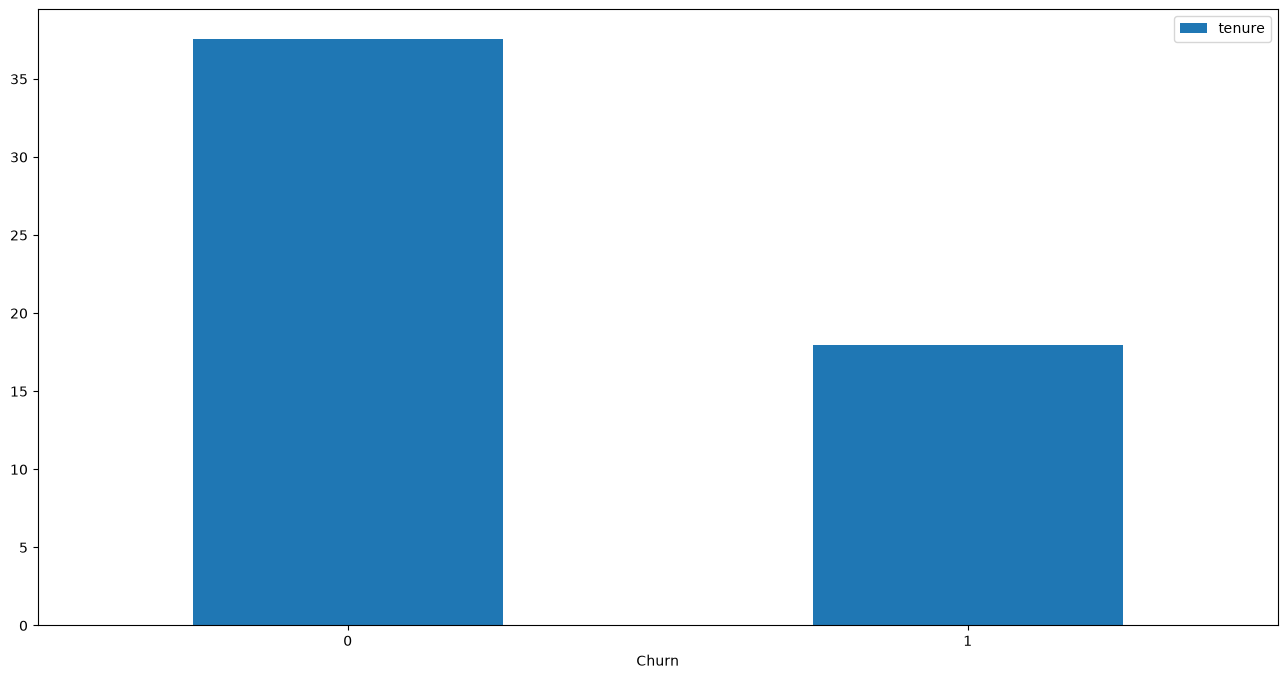

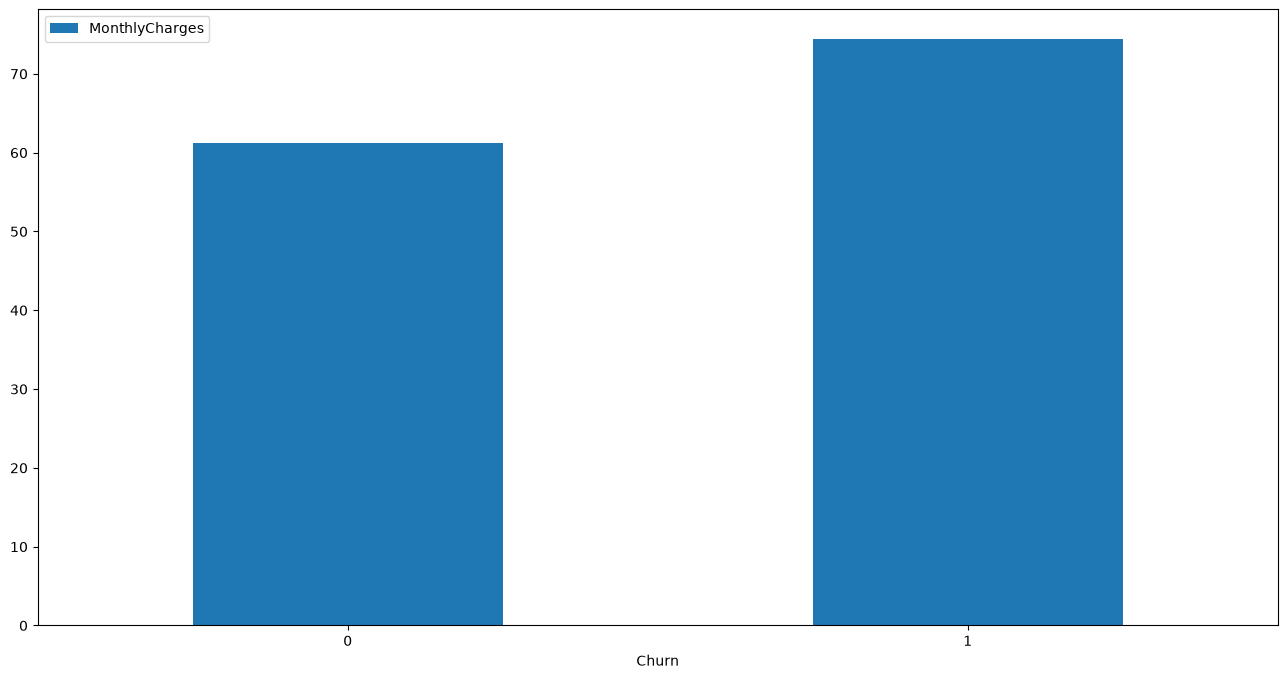

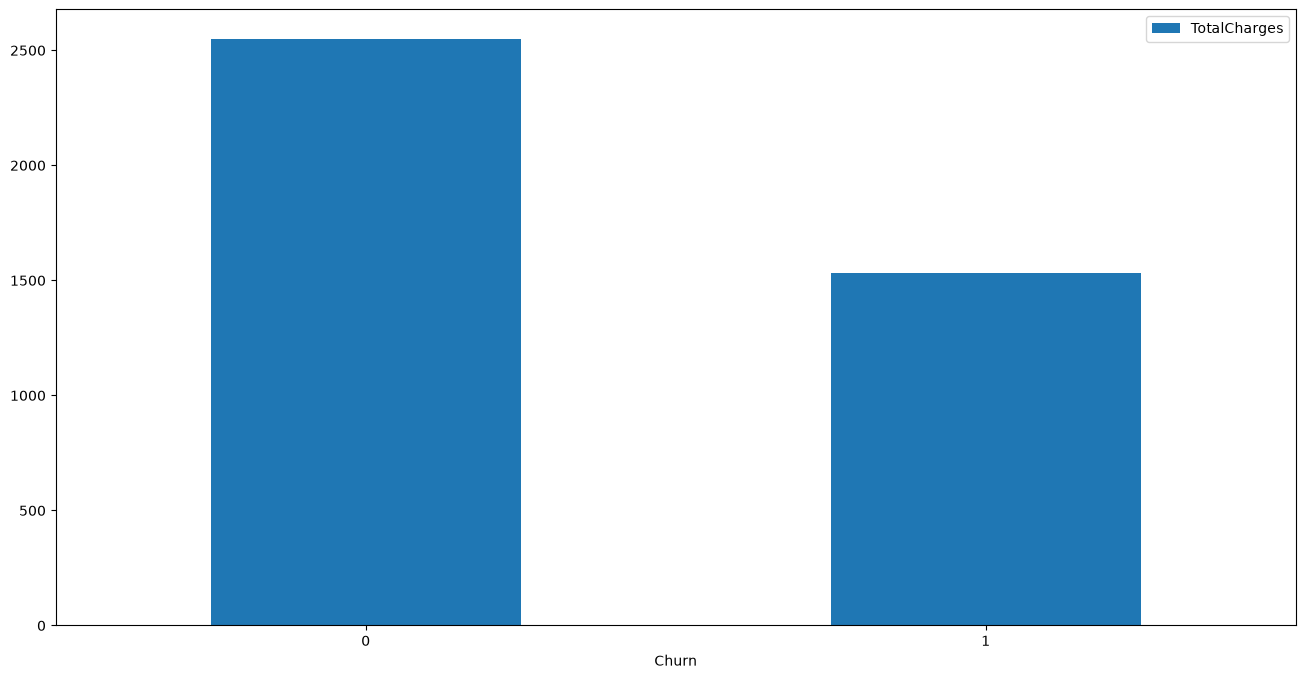

In [30]:
for col in num_cols:
    df.groupby('Churn').agg({col:'mean'}).plot(kind='bar', rot = 0,figsize=(16,8))

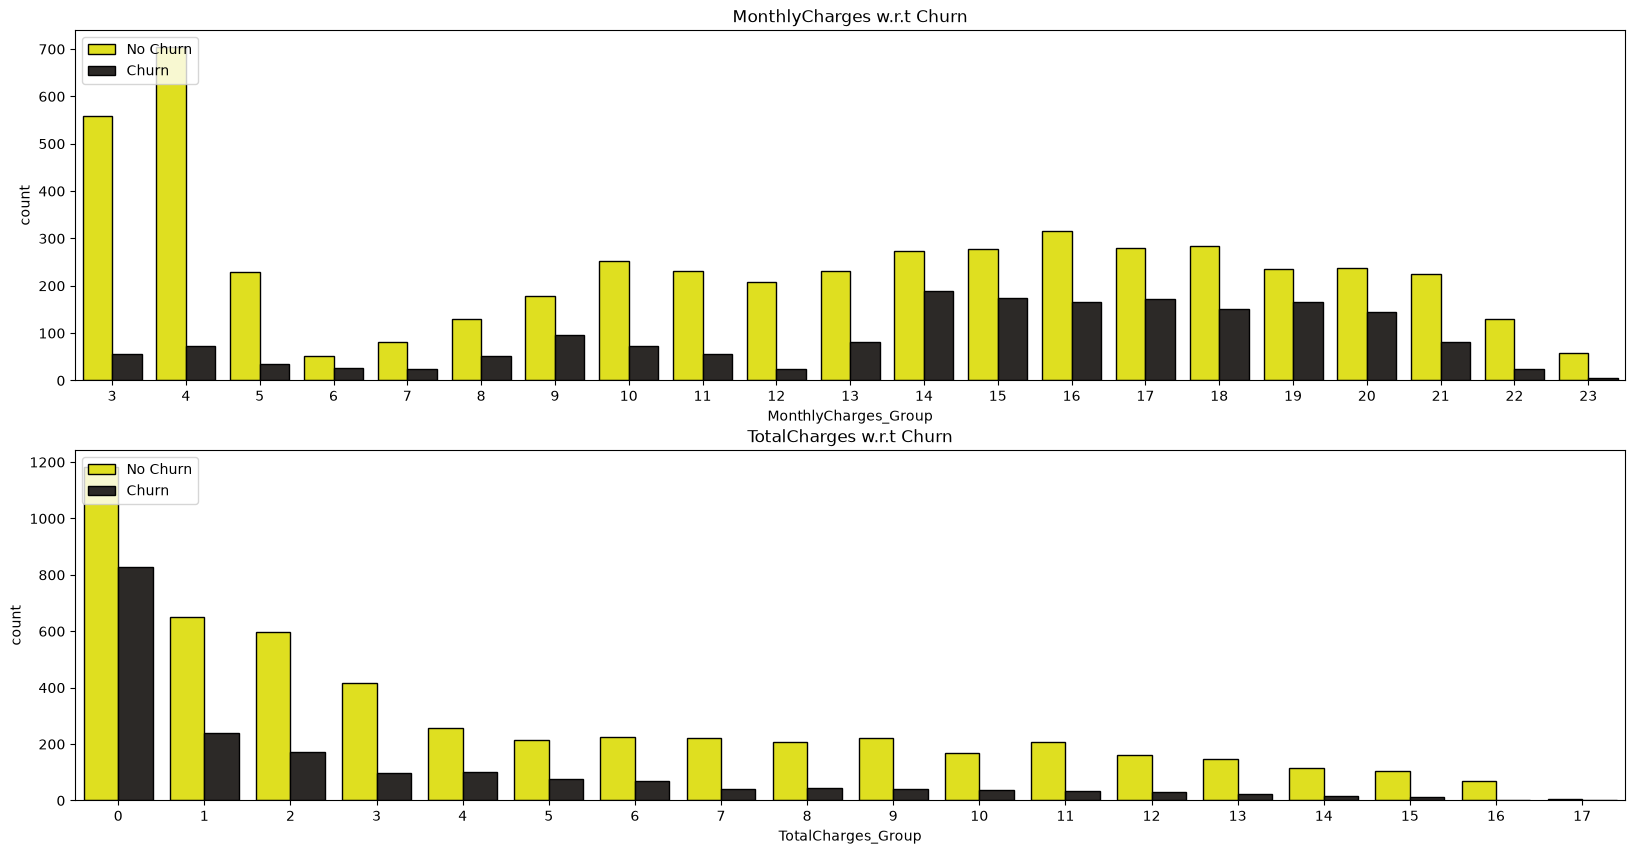

In [31]:
df['MonthlyCharges_Group'] = [int(i / 5) for i in df['MonthlyCharges']]
df['TotalCharges_Group'] = [int(i / 500) for i in df['TotalCharges']]

fig, ax = plt.subplots(nrows = 2,ncols = 1,figsize = (20,10))
for i in range(len(num_cols[1:])):
    plt.subplot(2,1,i+1)
    sns.countplot(x = num_cols[1 + i]+'_Group',data = df,hue = "Churn",palette = colors,edgecolor = 'black')
    plt.legend(['No Churn','Churn'],loc = 'upper left')
    title = num_cols[1 + i] + ' w.r.t Churn'
    plt.title(title);

## Comment
The churn rate is high for the MonthlyCharges group in the 65 (13x5) to 105 (21x5) range. This MonthlyCharges range caused customers to switch.

A very large number of customers discontinued the services when TotalCharges were below 500.

## Numerical features vs Categorical features w.r.t Target variable (Churn)

In [32]:
l1 = ['gender','SeniorCitizen','Partner','Dependents'] # Customer Information
l2 = ['PhoneService','MultipleLines','InternetService','StreamingTV','StreamingMovies',
      'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport'] # Services Signed Up for!
l3 = ['Contract','PaperlessBilling','PaymentMethod'] # Payment Information

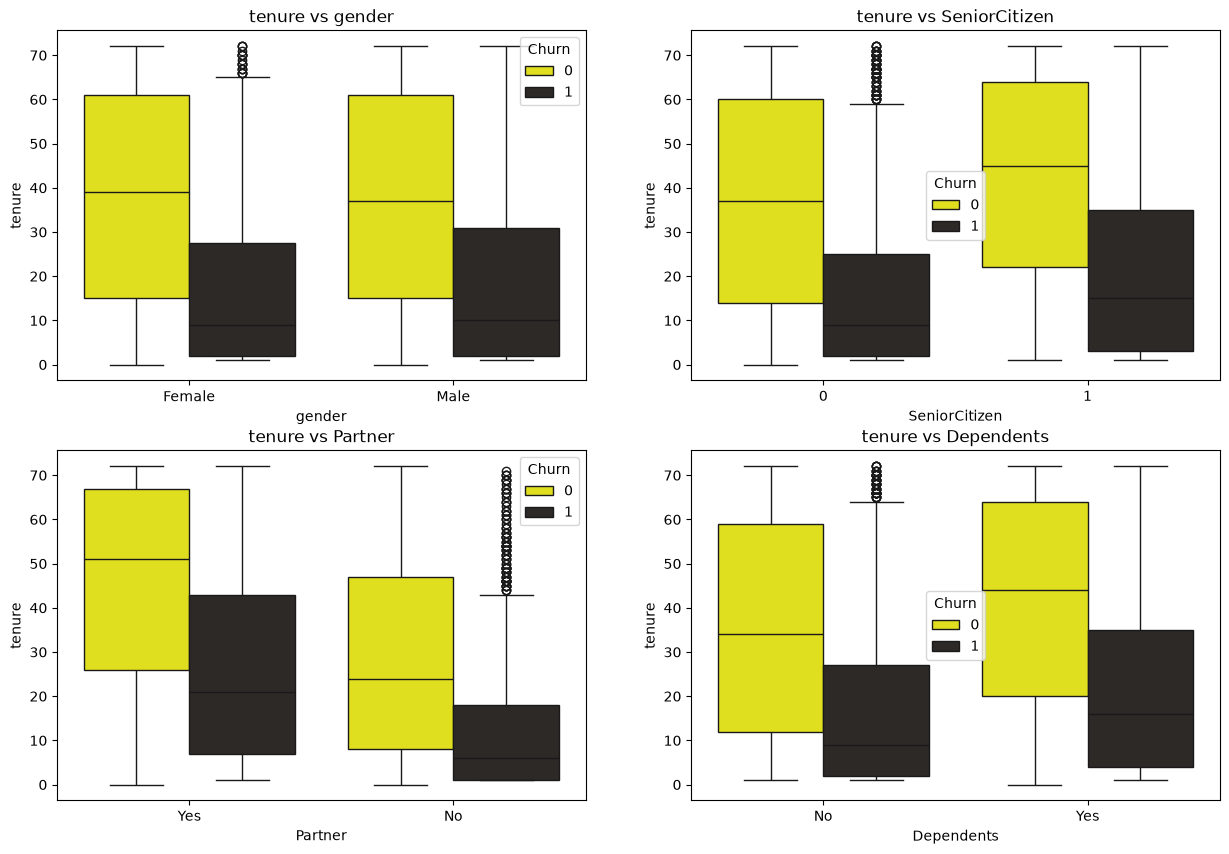

In [33]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (15,10))
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = l1[i],y = 'tenure',data = df,hue = 'Churn',palette = colors);
    plt.title('tenure vs ' + l1[i]);
    

## Observations

* The churn graphs for male and female customers are very similar.

* Senior citizens discontinued the service after usage periods ranging from 0 to 35 months. The 20-to-35-month mark appears to be a decision-making period regarding whether to continue the service or switch.

* Similarly, customers with partners continued to use the service for periods ranging from 5 to 45 months.

## tenure vs Group 2: Services Subscribed by the Customer : PhoneService | MultipleLines | InternetService | StreamingTV | StreamingMovies

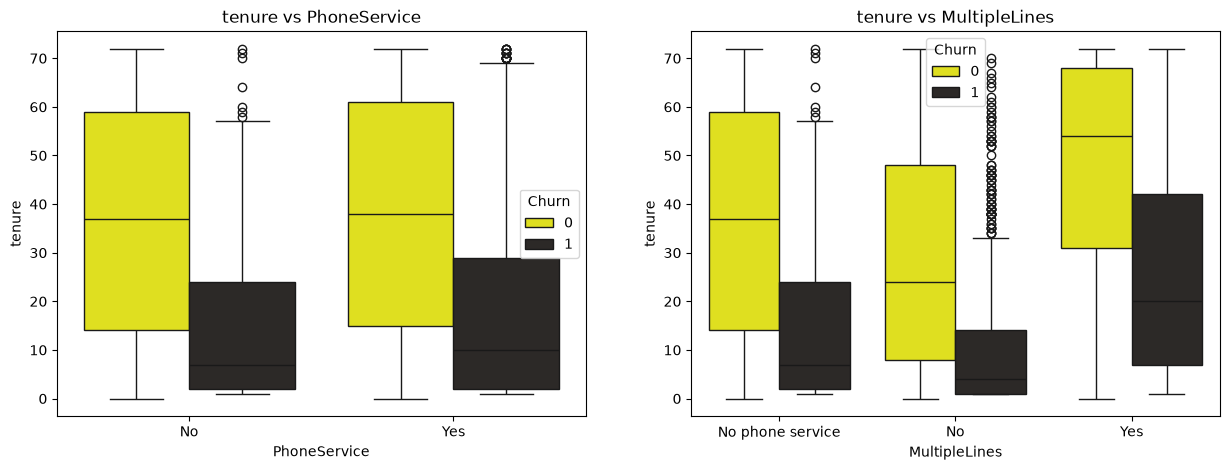

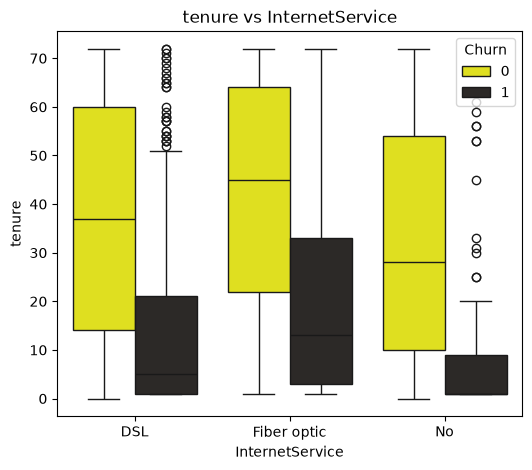

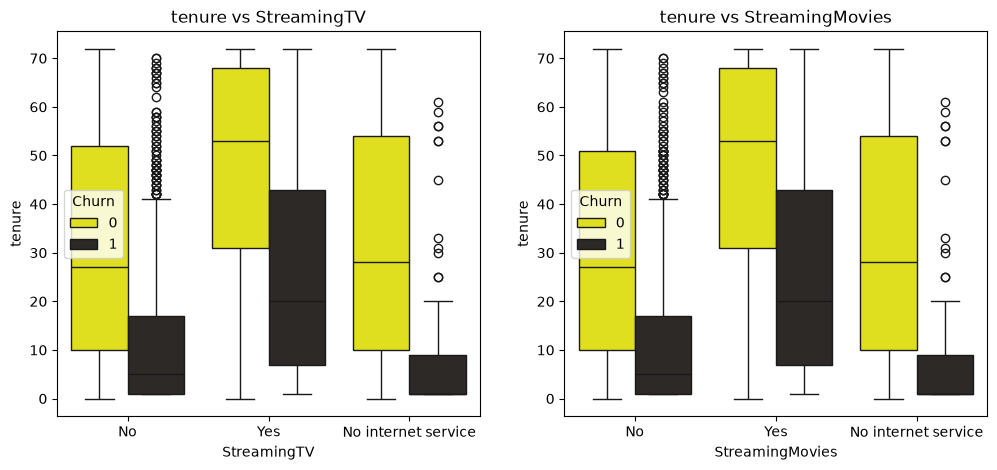

In [34]:
fig = plt.subplots(nrows = 1,ncols = 2,figsize = (15,5))

for i in range(len(l2[0:2])):
    plt.subplot(1,2,i + 1)
    ax = sns.boxplot(x = l2[i],y = 'tenure',data = df,hue = 'Churn',palette = colors);
    plt.title('tenure vs ' + l2[i]);

fig = plt.subplots(nrows = 1, ncols = 1, figsize = (6,5))

plt.subplot(1,1,1)
ax = sns.boxplot(x = l2[2],y = 'tenure',data = df,hue = 'Churn',palette = colors);
plt.title('tenure vs ' + l2[2]);
    
fig = plt.subplots(nrows = 1,ncols = 2,figsize = (12,5))

for i in range(len(l2[3:5])):
    plt.subplot(1,2,i + 1)
    ax = sns.boxplot(x = l2[i + 3],y = 'tenure',data = df,hue = 'Churn',palette = colors);
    plt.title('tenure vs ' + l2[i + 3]);

## Observations
The presence of "MultipleLines" drives up average monthly charges, regardless of whether customers opt out of the services.

Regarding the usage duration and "PhoneService" graph—which visualizes the availability or absence of the service—it appears that the customers were not heavy phone users (calls/messaging).

For "InternetService," customers seem quite skeptical about using fiber optic cables, as there is a period of approximately 30–35 months of non-usage before they either proceed with the existing cable or switch to a new one.

Similarly, for "StreamingTV" and "StreamingMovies," a non-usage period of approximately 10–40 months can be observed.

## tenure vs Group 2: Services Subscribed by the Customer : OnlineSecurity | OnlineBackup | DeviceProtection | TechSupport

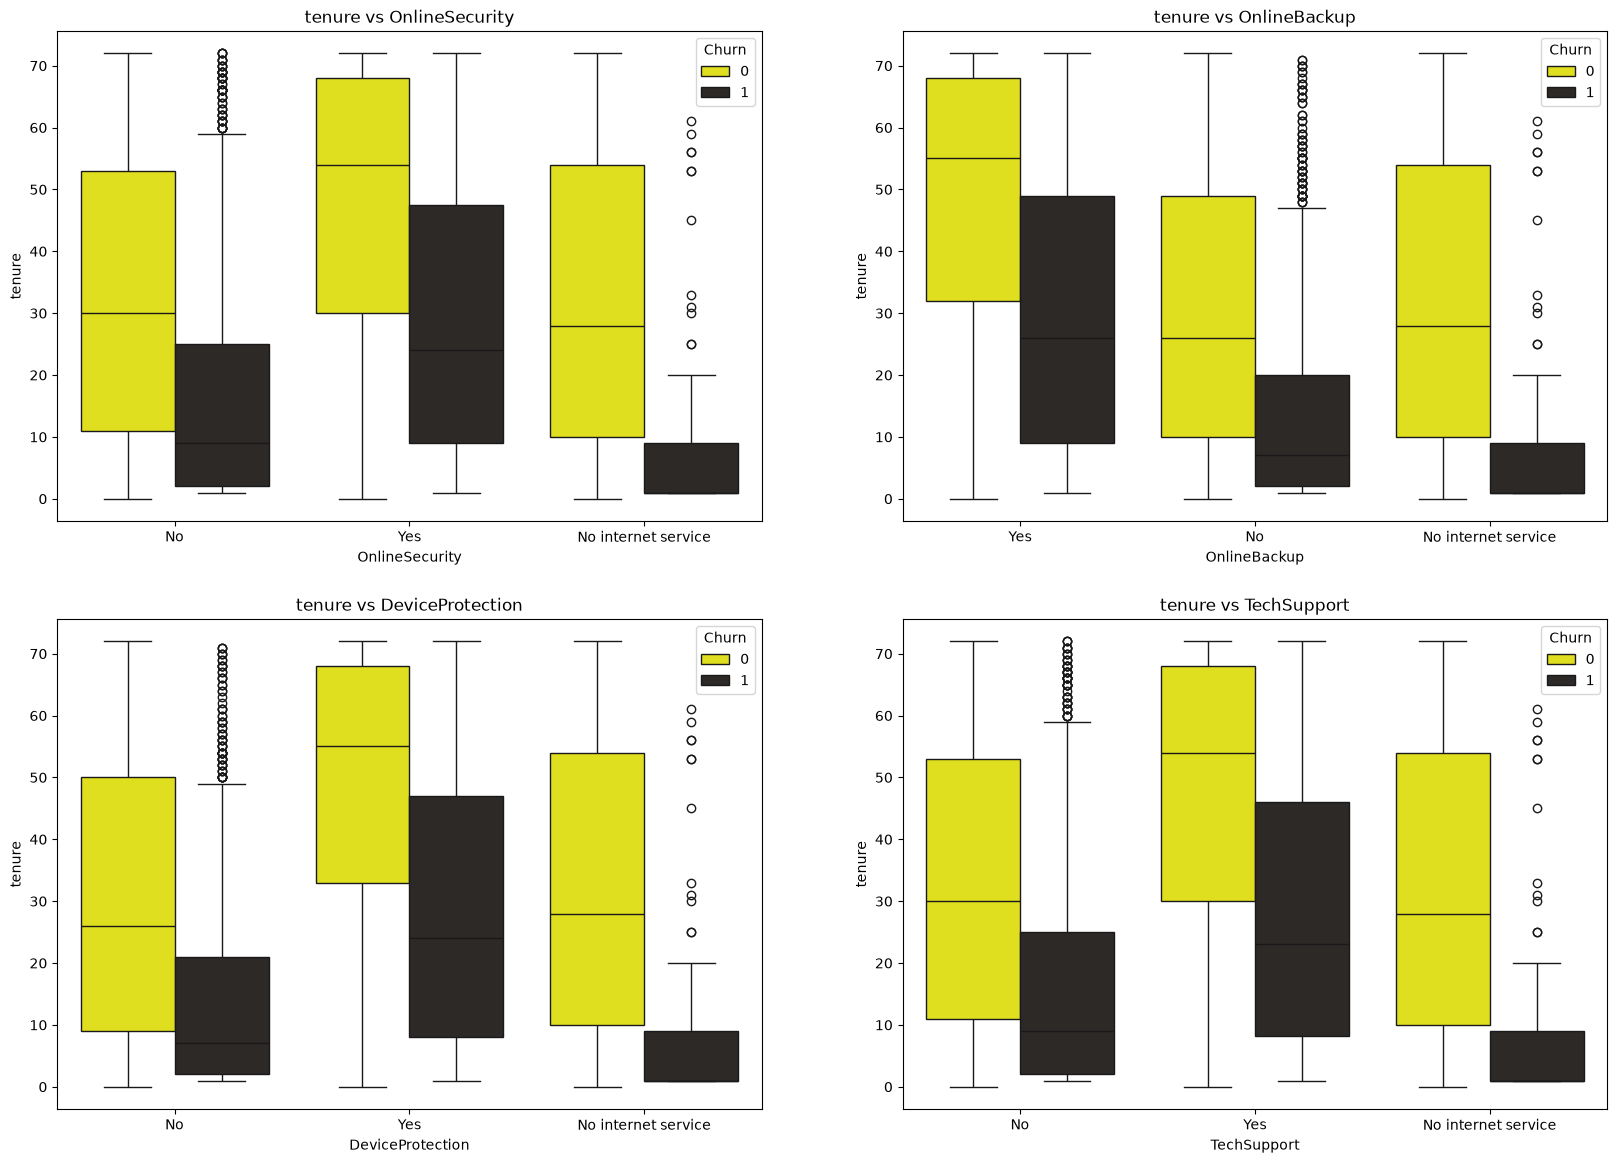

In [35]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (20,14))
for i in range(len(l2[-4:])):
    plt.subplot(2,2,i + 1)
    ax = sns.boxplot(x = l2[i - 4],y = 'tenure',data = df,hue = 'Churn',palette = colors);
    plt.title('tenure vs ' + l2[i-4]);

## Comments
The average duration of lost usage for OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport is 25 months. The maximum duration of this lost usage is approximately 45 months.

The 30–35 month period is when customers have a phone conversation to decide whether to continue with their current services or switch to the features mentioned above.



## tenure vs Group 3 : Contract | PaperlessBilling | PaymentMethod |¶¶

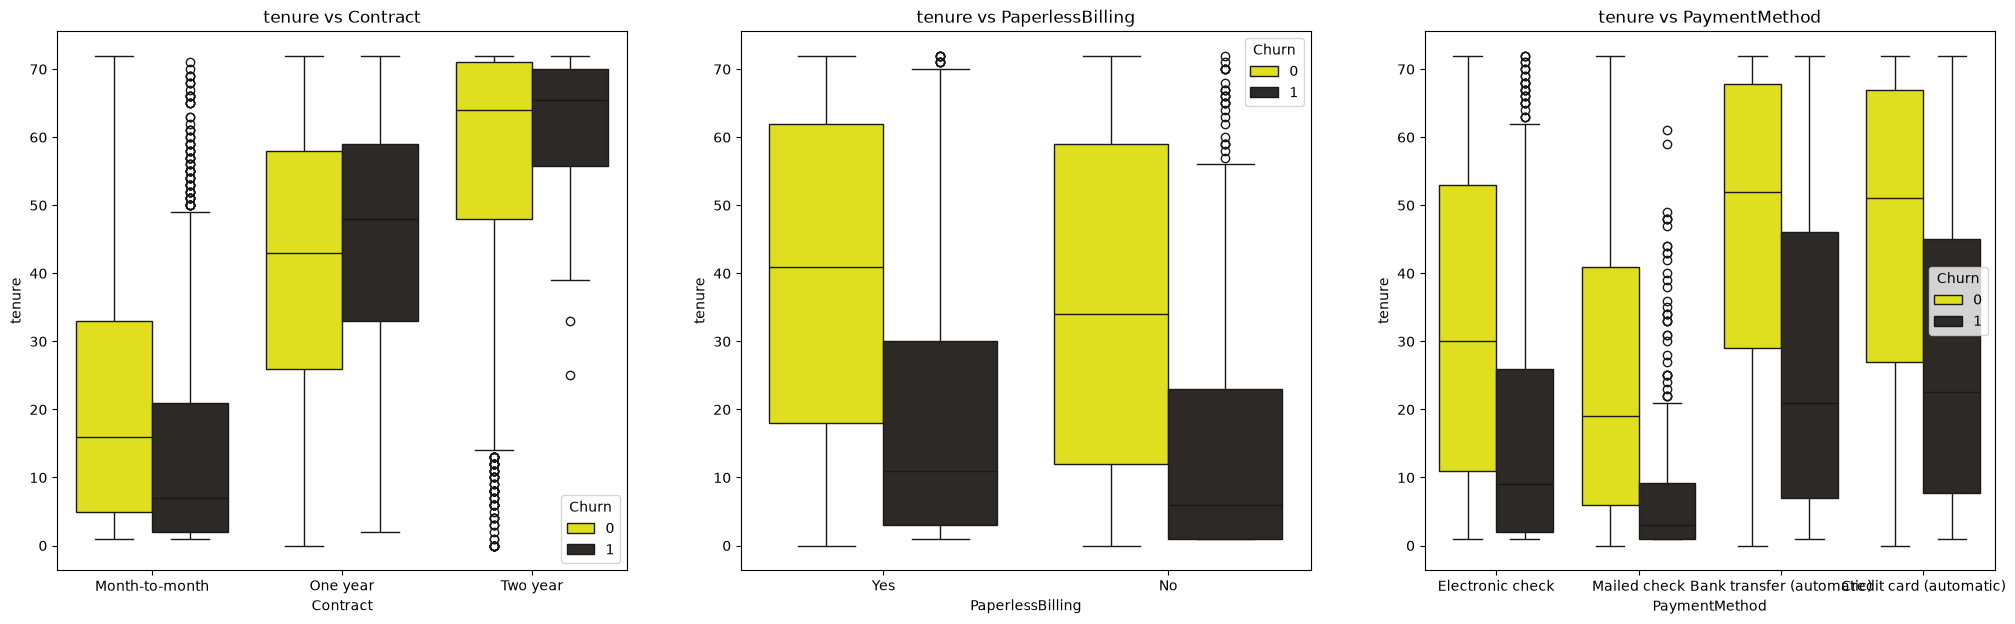

In [36]:
fig = plt.subplots(nrows = 1,ncols = 3,figsize = (25,7))
for i in range(len(l3)):
    plt.subplot(1,3,i + 1)
    ax = sns.boxplot(x = l3[i],y = 'tenure',data = df,hue = 'Churn',palette = colors);
    plt.title('tenure vs ' + l3[i]);

## Observations
When customers sign one-year or two-year service contracts, they appear likely to maintain the services for approximately 25 and 45 months, respectively. However, they begin to question the service and consider switching around the 35-month and 55-month marks, respectively.

Regardless of paperless billing, customers consider switching as early as the first month.

Regarding payment methods, the average tenure before churn for Bank Transfer (automatic) and Credit Card (automatic) is over 20 months—nearly double that of electronic checks and postal checks (approximately 10 months and 5 months, respectively).

## MonthlyCharges vs Group 1 : Customer Information : gender | SeniorCitizen | Partner | Dependents

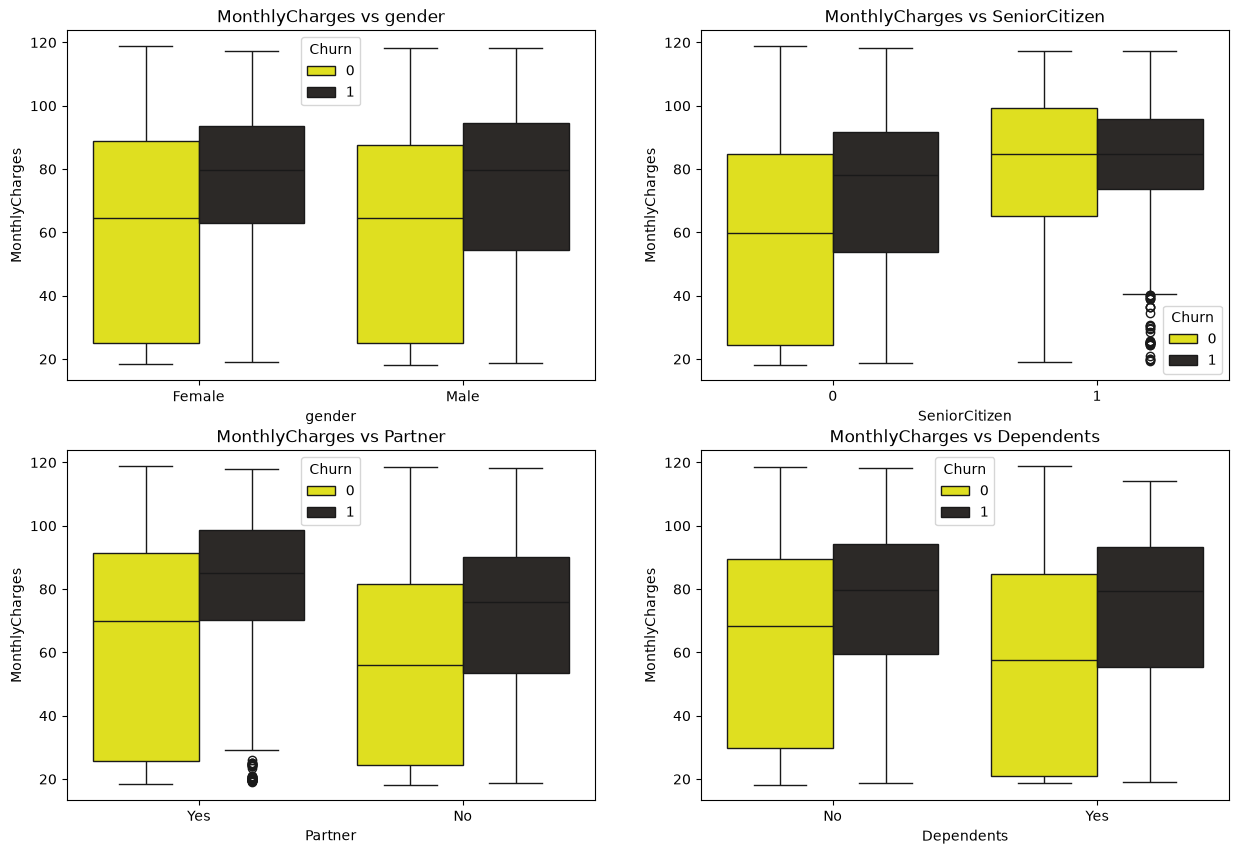

In [37]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (15,10))
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = l1[i],y = 'MonthlyCharges',data = df,hue = 'Churn',palette = colors); 
    plt.title('MonthlyCharges vs ' + l1[i]);

## Observations
For all the aforementioned characteristics, the median value for customers who do not churn is very close to the lower bound for that group.

The average Monthly Charges for both male and female customers are around 60. For senior citizens, this figure rises to 80.

Customers living with a partner have a higher lower-bound threshold for Monthly Charges (associated with churn) compared to those living alone; for the latter, the Monthly Charges figure is just under 60.

## MonthlyCharges vs Group 2: Services Subscribed by the Customer : PhoneService | MultipleLines | InternetService | StreamingTV | StreamingMovies

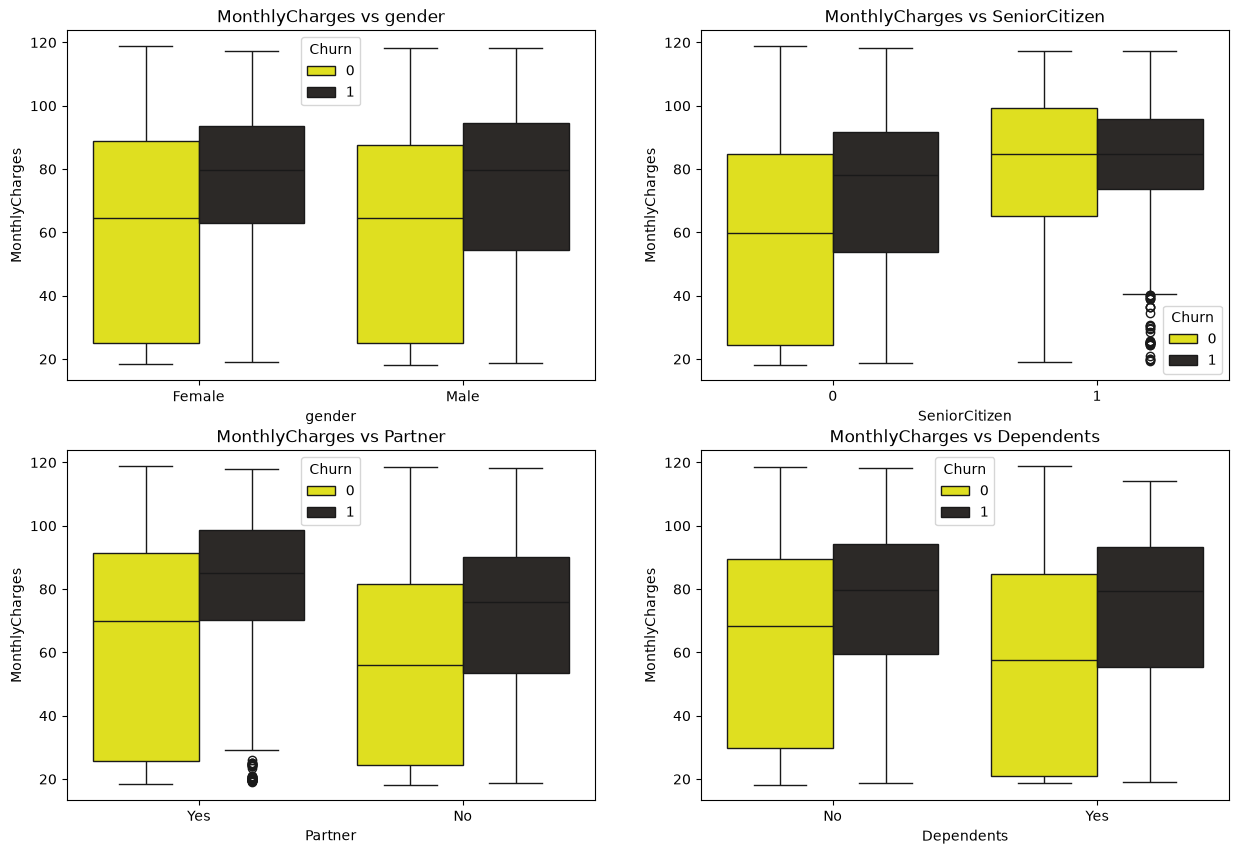

In [38]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (15,10))
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = l1[i],y = 'MonthlyCharges',data = df,hue = 'Churn',palette = colors); 
    plt.title('MonthlyCharges vs ' + l1[i]);

## Observations
For all the aforementioned characteristics, the median value for customers who do not churn is very close to the lower bound for that group.

The average Monthly Charges for both male and female customers are around 60. For senior citizens, this figure rises to 80.

Customers living with a partner have a higher lower-bound threshold for Monthly Charges (associated with churn) compared to those living alone; for the latter, the Monthly Charges figure is just under 60.

## MonthlyCharges vs Group 2: Services Subscribed by the Customer : PhoneService | MultipleLines | InternetService | StreamingTV | StreamingMovies

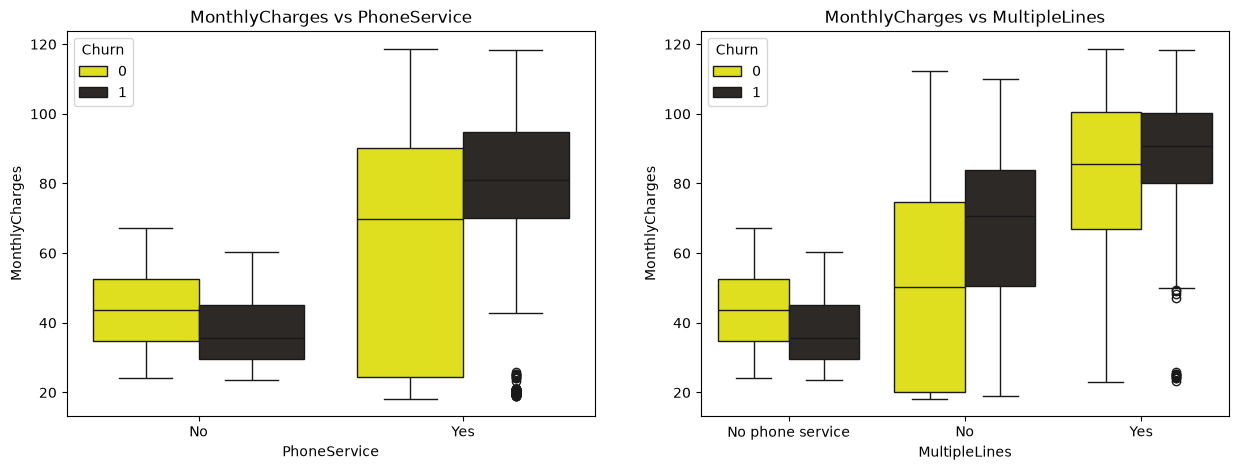

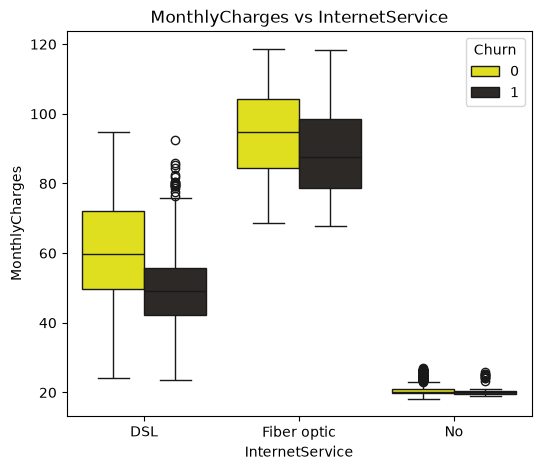

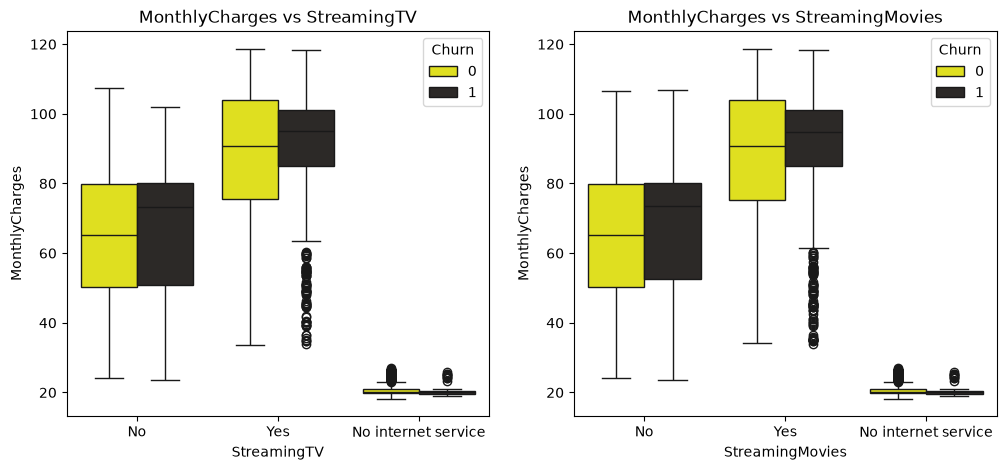

In [39]:
fig = plt.subplots(nrows = 1,ncols = 2,figsize = (15,5))

for i in range(len(l2[0:2])):
    plt.subplot(1,2,i + 1)
    ax = sns.boxplot(x = l2[i],y = 'MonthlyCharges',data = df,hue = 'Churn',palette = colors);
    plt.title('MonthlyCharges vs ' + l2[i]);

fig = plt.subplots(nrows = 1, ncols = 1, figsize = (6,5))

plt.subplot(1,1,1)
ax = sns.boxplot(x = l2[2],y = 'MonthlyCharges',data = df,hue = 'Churn',palette = colors);
plt.title('MonthlyCharges vs ' + l2[2]);
    
fig = plt.subplots(nrows = 1,ncols = 2,figsize = (12,5))

for i in range(len(l2[3:5])):
    plt.subplot(1,2,i + 1)
    ax = sns.boxplot(x = l2[i + 3],y = 'MonthlyCharges',data = df,hue = 'Churn',palette = colors);
    plt.title('MonthlyCharges vs ' + l2[i + 3]);

## Comments¶
The monthly charges for fiber optic cables are very high. This could be the reason for such high customer churn.

Similarly, the monthly charges for StreamingTV and StreamingMovies are also quite high.

For PhoneService, the monthly charges range from 25 to 85, but customers consider cancelling their subscriptions when the monthly charge reaches 75.

## MonthlyCharges vs Group 2: Services Subscribed by the Customer : OnlineSecurity | OnlineBackup | DeviceProtection | TechSupport

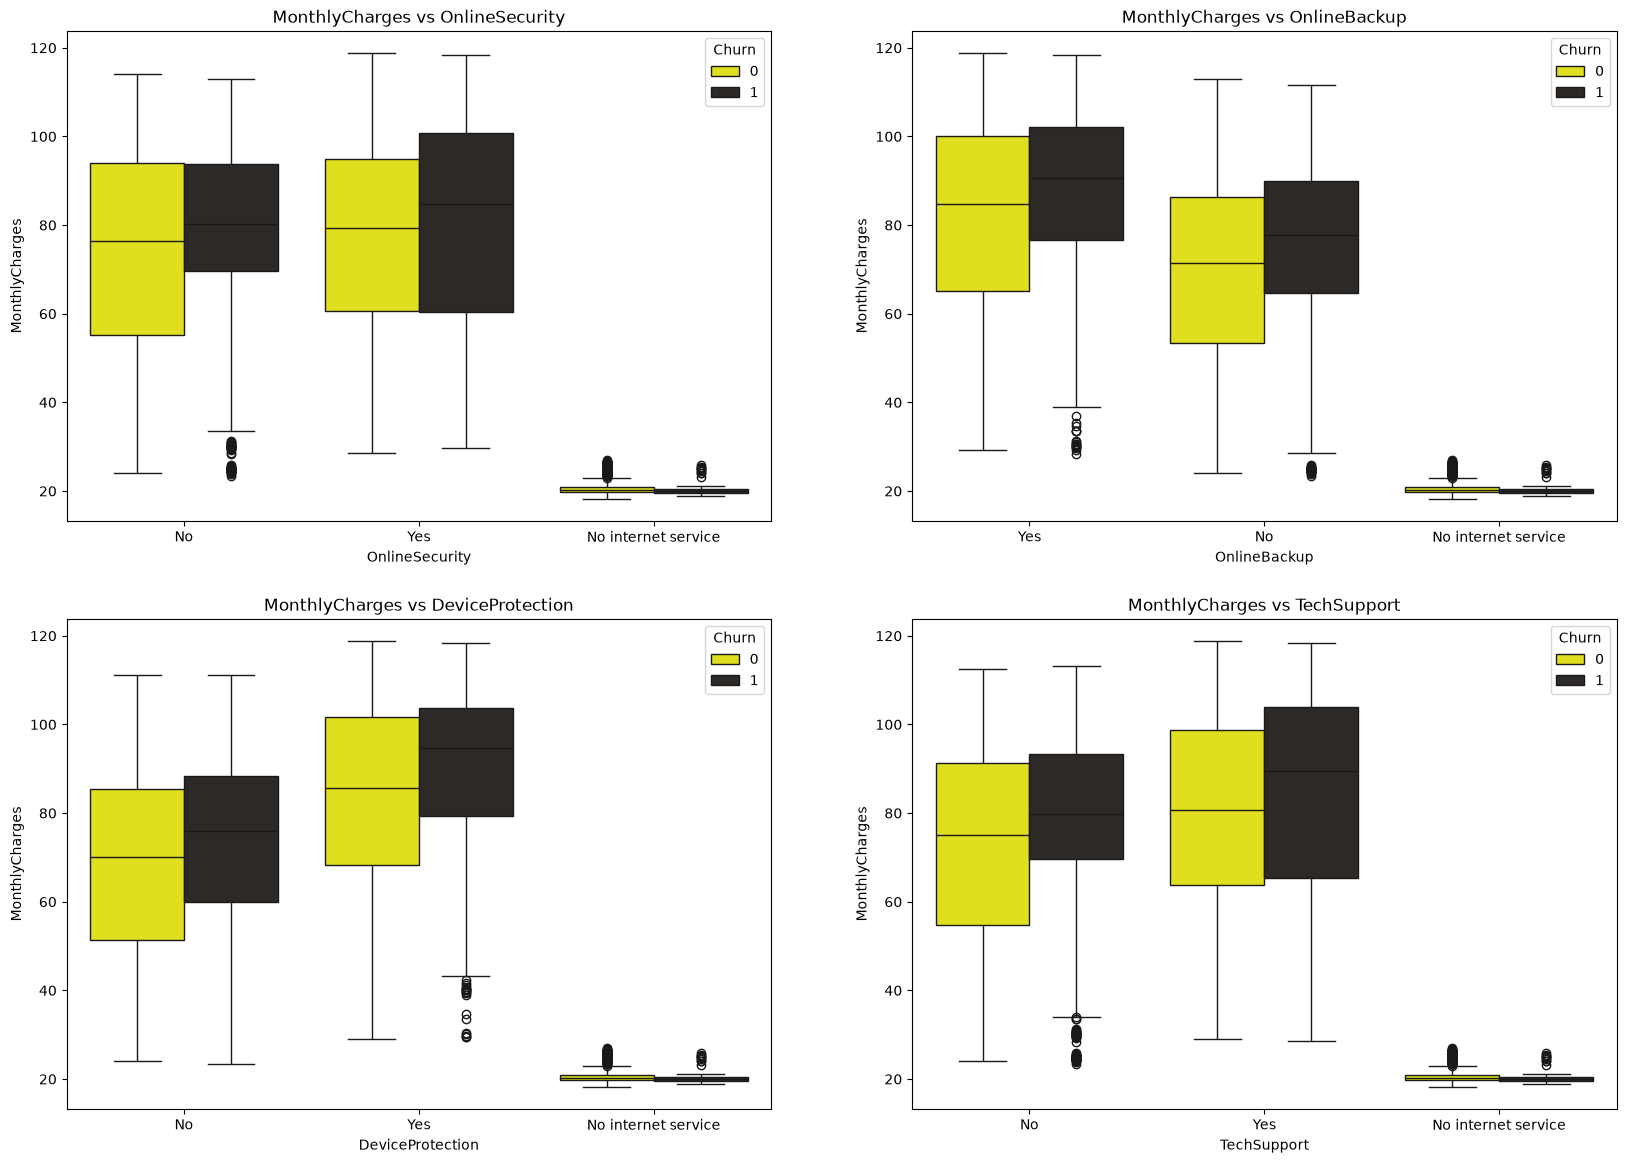

In [40]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (20,14))
for i in range(len(l2[-4:])):
    plt.subplot(2,2,i + 1)
    ax = sns.boxplot(x = l2[i - 4],y = 'MonthlyCharges',data = df,hue = 'Churn',palette = colors);
    plt.title('MonthlyCharges vs ' + l2[i-4]);

## Comments
The value range for OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport is approximately between 50 and 100.

Customers subscribed to these services likely do not consider cancelling due to MonthlyCharges, as the value range for both those who unsubscribe and those who remain is virtually the same!

## MonthlyCharges vs Group 3 : Contract | PaperlessBilling | PaymentMethod

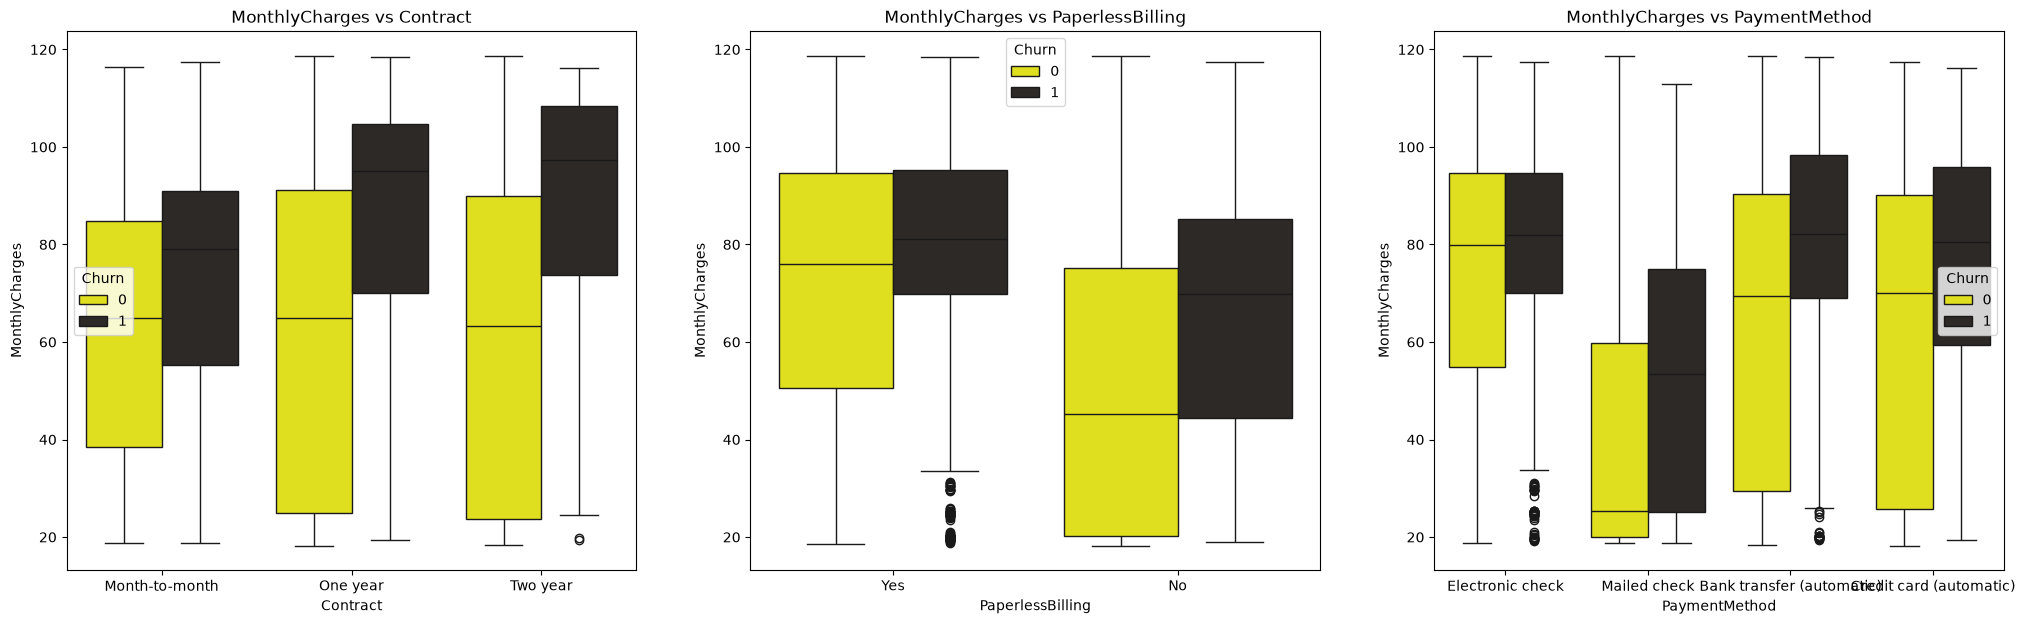

In [41]:
fig = plt.subplots(nrows = 1,ncols = 3,figsize = (25,7))

for i in range(len(l3)):
    plt.subplot(1,3,i + 1)
    ax = sns.boxplot(x = l3[i],y = 'MonthlyCharges',data = df,hue = 'Churn',palette = colors);
    title = 'MonthlyCharges vs ' + l3[i]
    plt.title(title);

## Comments
The minimum threshold for monthly fees is higher for month-to-month contracts than for one-year or two-year contracts. However, the threshold is lower for customers who discontinue the service under monthly contracts.

The minimum threshold for electronic checks is very high, which could be a major factor causing customers to decide against using them!

Postal checks, on the other hand, have the lowest initial thresholds for both departing and continuing customers.

## TotalCharges vs Group 1 : Customer Information : gender | SeniorCitizen | Partner | Dependents

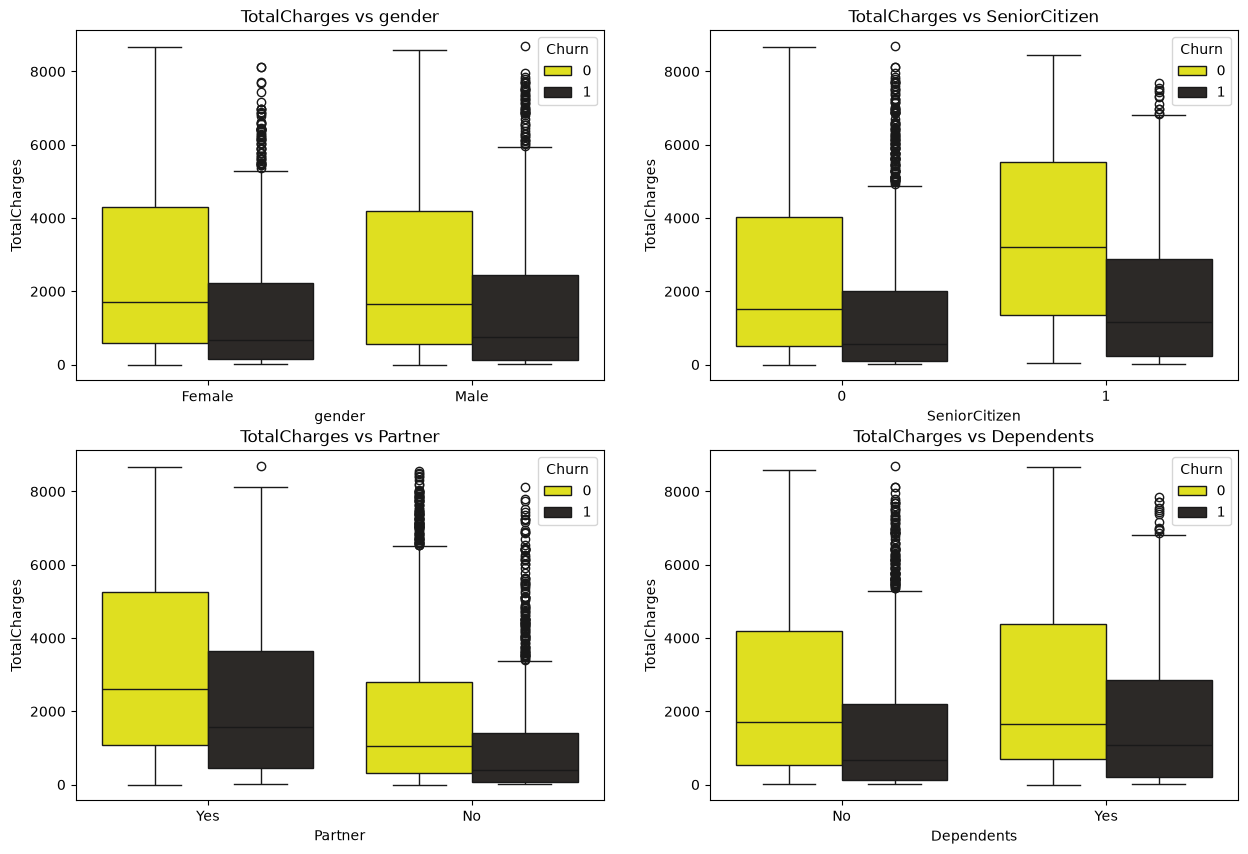

In [42]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (15,10))
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = l1[i],y = 'TotalCharges',data = df,hue = 'Churn',palette = colors);
    plt.title('TotalCharges vs ' + l1[i]);

## Comments
Total costs are exactly the same for male and female customers! For senior citizens who continue to receive the service, the starting and closing values ​​for total costs are higher.

The average total cost for customers living with their spouses is higher compared to those living alone!

## TotalCharges vs Group 2: Services Subscribed by the Customer : PhoneService | MultipleLines | InternetService | StreamingTV | StreamingMovies

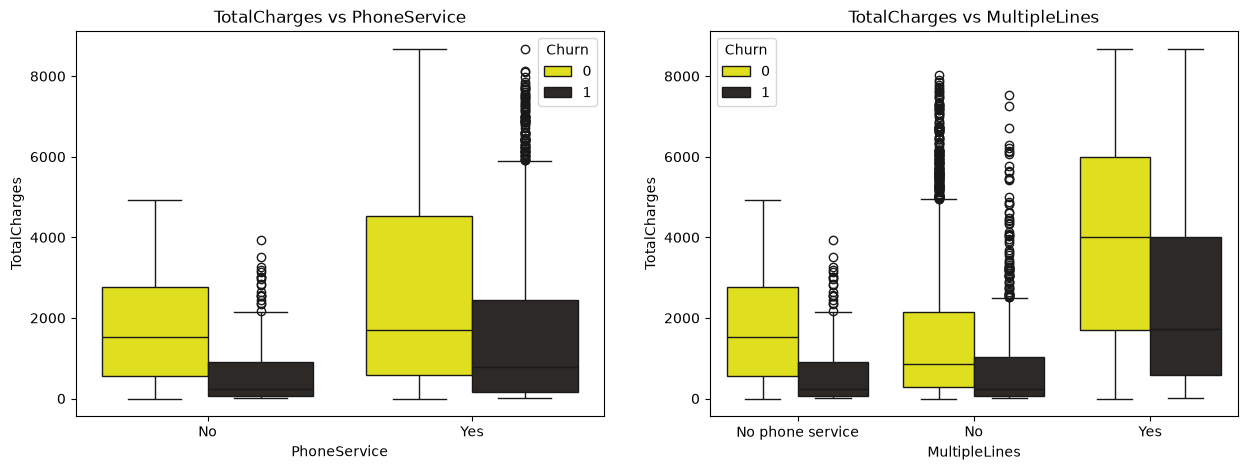

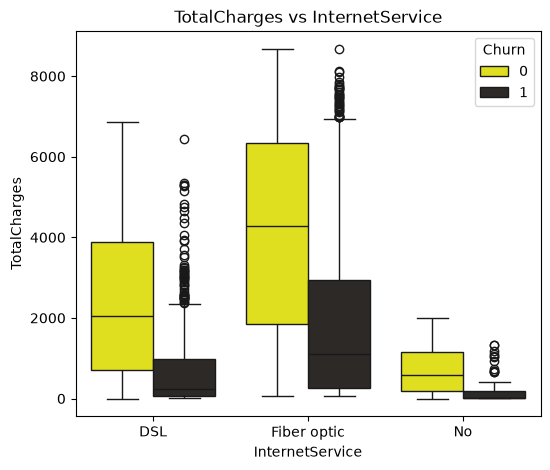

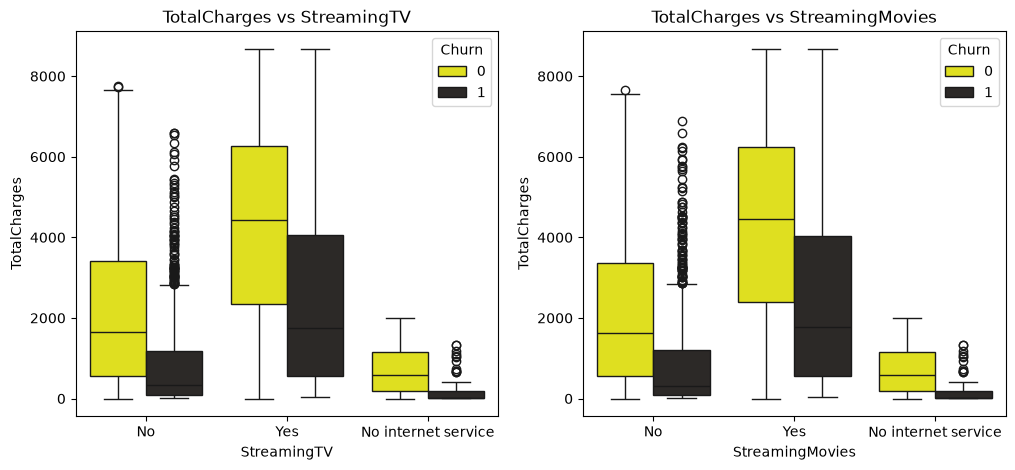

In [43]:
fig = plt.subplots(nrows = 1,ncols = 2,figsize = (15,5))

for i in range(len(l2[0:2])):
    plt.subplot(1,2,i + 1)
    ax = sns.boxplot(x = l2[i],y = 'TotalCharges',data = df,hue = 'Churn',palette = colors);
    plt.title('TotalCharges vs ' + l2[i]);

fig = plt.subplots(nrows = 1, ncols = 1, figsize = (6,5))

plt.subplot(1,1,1)
ax = sns.boxplot(x = l2[2],y = 'TotalCharges',data = df,hue = 'Churn',palette = colors);
plt.title('TotalCharges vs ' + l2[2]);
    
fig = plt.subplots(nrows = 1,ncols = 2,figsize = (12,5))

for i in range(len(l2[3:5])):
    plt.subplot(1,2,i + 1)
    ax = sns.boxplot(x = l2[i + 3],y = 'TotalCharges',data = df,hue = 'Churn',palette = colors);
    plt.title('TotalCharges vs ' + l2[i + 3]);

## Comments
Total charges for Phone Service range from 0 to 4,000. However, customers begin to have second thoughts about the Phone Service once the total charges reach around the 1,000 mark.

Similarly, customers start to hesitate about paying around 2,000 for MultipleLines. Yet, some customers appear disheartened after paying around 6,000 for MultipleLines!

As for Fiber Optic cable, customers test the products by paying around 2,000!

Customers who continue with services such as Fiber Optic, StreamingTV, and StreamingMovies pay between 3,000 and 6,000.

## TotalCharges vs Group 2: Services Subscribed by the Customer : OnlineSecurity | OnlineBackup | DeviceProtection | TechSupport |

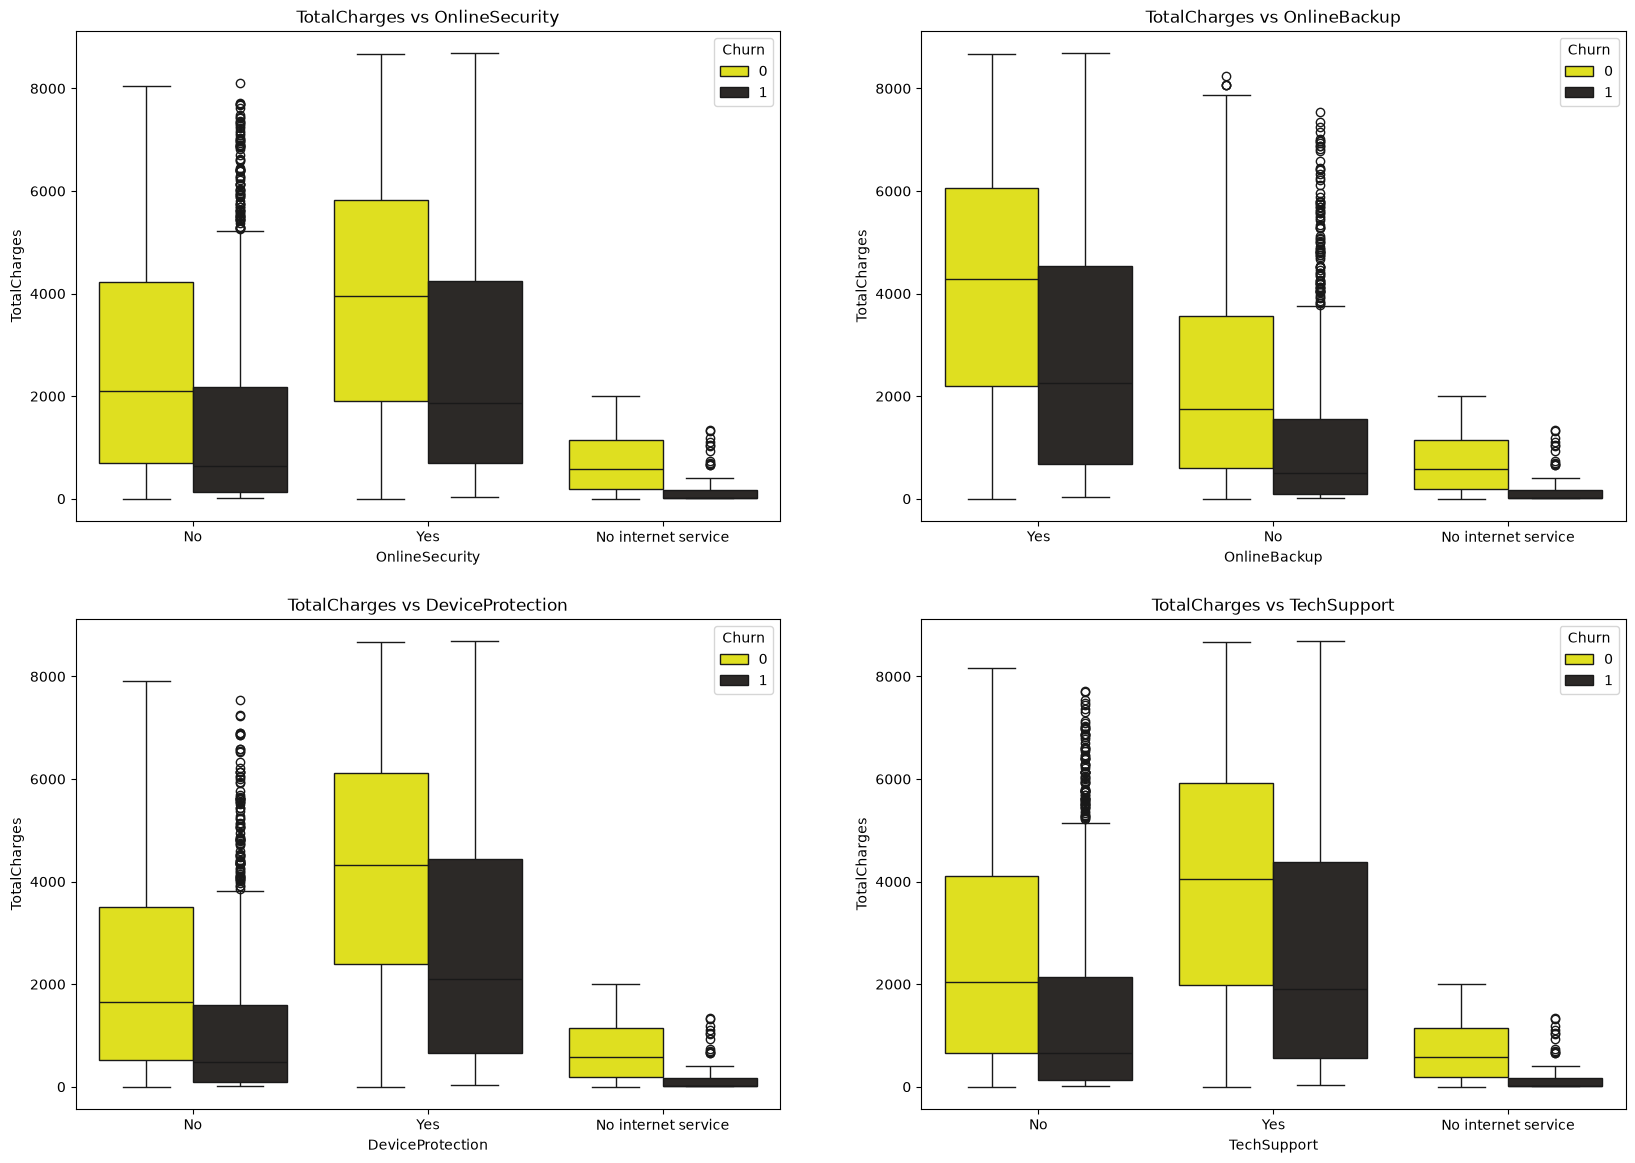

In [44]:
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (20,14))
for i in range(len(l2[-4:])):
    plt.subplot(2,2,i + 1)
    ax = sns.boxplot(x = l2[i - 4],y = 'TotalCharges',data = df,hue = 'Churn',palette = colors);
    plt.title('TotalCharges vs ' + l2[i-4]);

## Comments
Regarding all the features mentioned above, customers began to grow skeptical about paying for them around the year 2000. This median value for lost customers is very close to the lower limit of the total fees paid by customers who retained the service.

Customers who do not unsubscribe are willing to pay a total fee ranging from 2,000 to 6,000.

## TotalCharges vs Group 3 : Contract | PaperlessBilling | PaymentMethod |¶

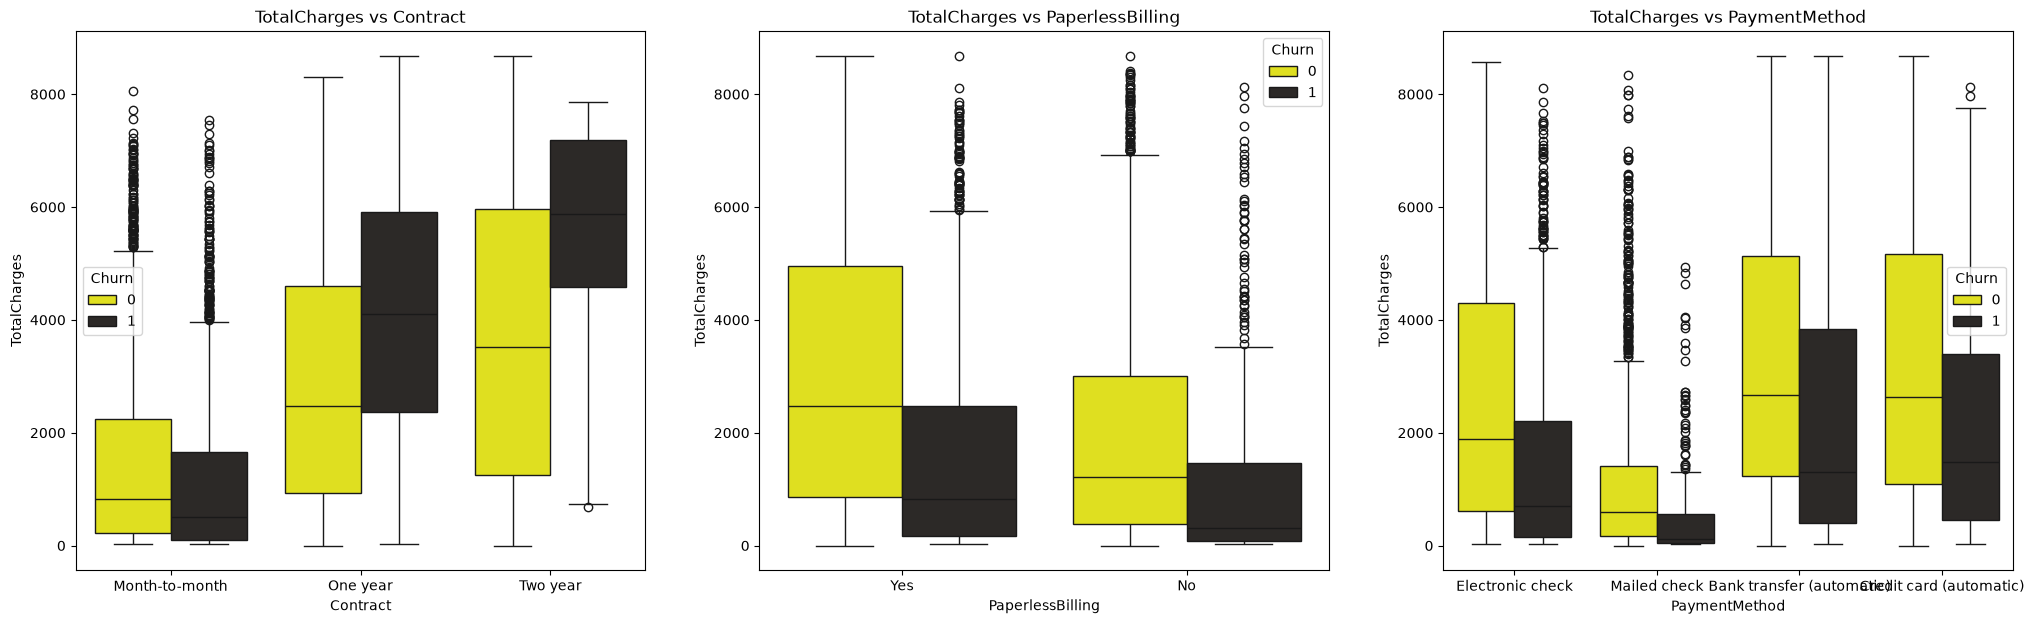

In [45]:
fig = plt.subplots(nrows = 1,ncols = 3,figsize = (25,7))

for i in range(len(l3)):
    plt.subplot(1,3,i + 1)
    ax = sns.boxplot(x = l3[i],y = 'TotalCharges',data = df,hue = 'Churn',palette = colors);
    plt.title('TotalCharges vs ' + l3[i]);

## Observations
The average values ​​for customers opting out of one-year and two-year contract services are high, hovering around 4,000 and 6,000, respectively. Some customers with two-year contracts even paid around 7,000.

Regarding PaymentMethod, while customers are hesitant to use electronic checks for the lower range of 0–2,000, this range extends to approximately 0–4,000 for Bank transfer (automatic) and Credit card (automatic) payments.

## Numerical features vs Numerical features w.r.t Target variable (Churn) :

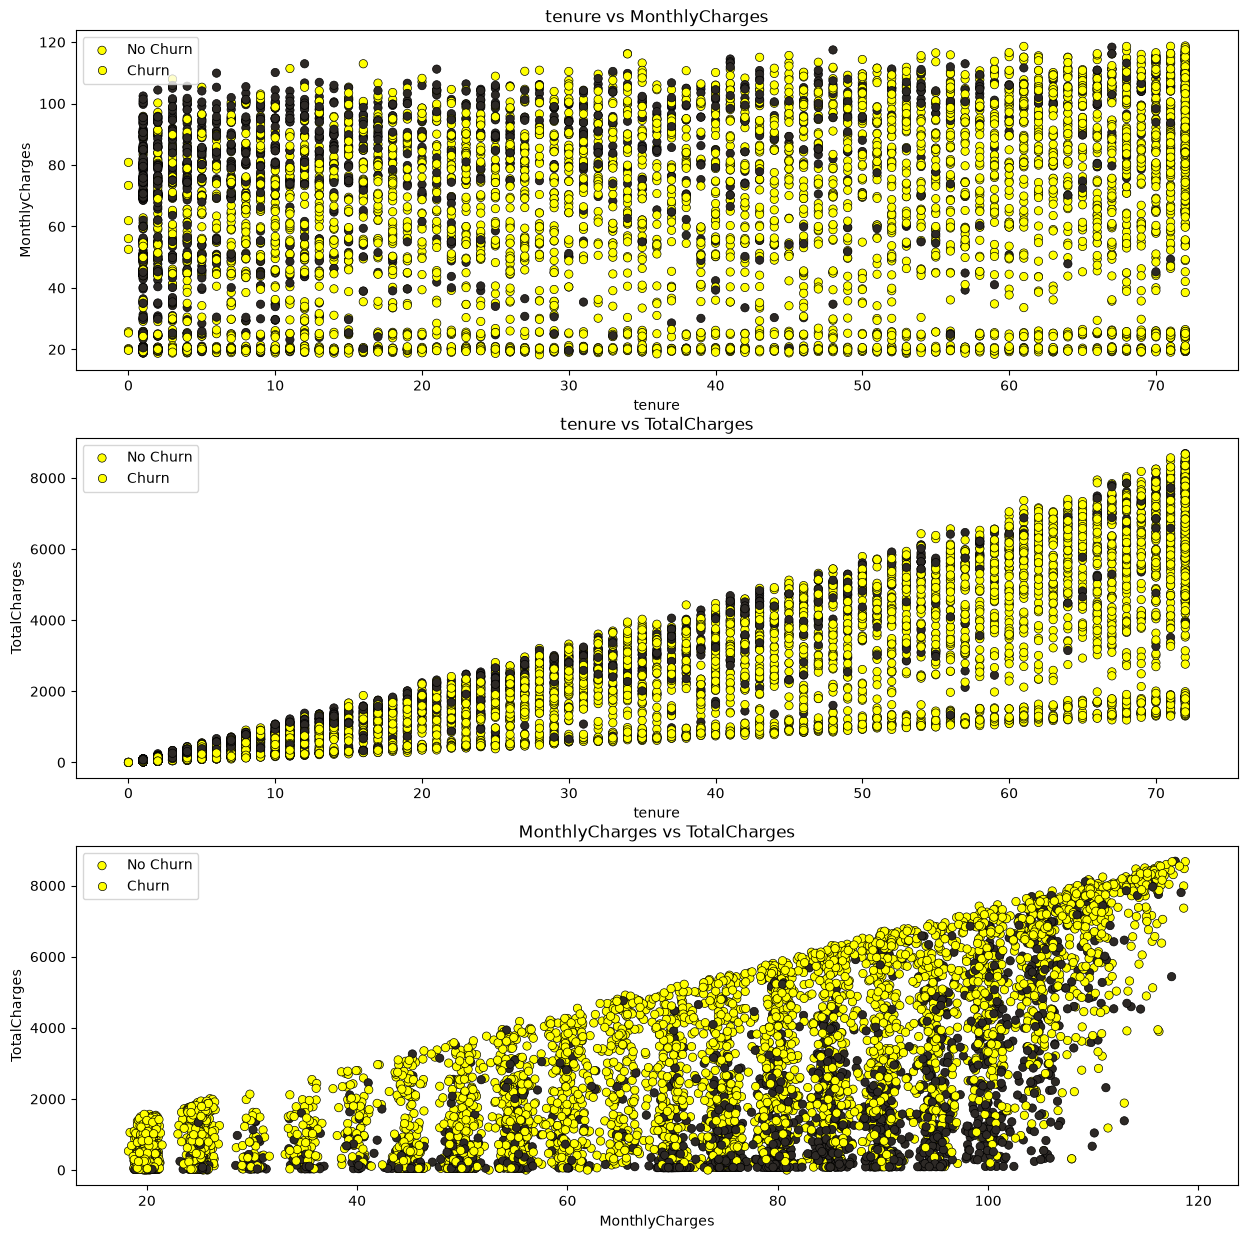

In [46]:
a = 0
fig,ax = plt.subplots(nrows = 3,ncols = 1,figsize = (15,15))
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        if i != j and j > i:
            a += 1
            plt.subplot(3,1,a)
            sns.scatterplot(x = num_cols[i],y = num_cols[j],data = df,hue = 'Churn',palette = colors,edgecolor = 'black');
            plt.legend(['No Churn','Churn'],loc = 'upper left',)
            title = num_cols[i] + ' vs ' + num_cols[j]
            plt.title(title)

## Comments
For a tenure of 0–20 months, there is significant fluctuation in the MonthlyCharges values ​​among customers.

During the 20–60 month tenure period, customers with MonthlyCharges at the upper end of the range (70–120) begin to churn.

Regarding TotalCharges and tenure: TotalCharges increase as tenure increases! The customers who leave their plans are those who incurred the highest charges during their tenure, as well as a few whose TotalCharges fell in the mid-range.

Customers appeared to decide to cancel their subscriptions once MonthlyCharges reached 70 or higher

## feature engineering

In [47]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
mms = MinMaxScaler() # Normalization
ss = StandardScaler() # Standardization

df.drop(columns = ['MonthlyCharges_Group','TotalCharges_Group'], inplace = True)

df['tenure'] = mms.fit_transform(df[['tenure']])
df['MonthlyCharges'] = mms.fit_transform(df[['MonthlyCharges']])
df['TotalCharges'] = mms.fit_transform(df[['TotalCharges']])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,0.013889,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,0.115423,0.003437,0
1,Male,0,No,No,0.472222,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,0.385075,0.217564,0
2,Male,0,No,No,0.027778,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,0.354229,0.012453,1
3,Male,0,No,No,0.625000,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),0.239303,0.211951,0
4,Female,0,No,No,0.027778,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,0.521891,0.017462,1


## Comments
Machine learning models do not understand the units associated with feature values; they treat the input simply as a number without grasping its actual meaning. Consequently, scaling the data becomes necessary.

We have two options for data scaling: 1) Normalization and 2) Standardization.

Since most algorithms assume a normal (Gaussian) distribution, normalization is applied to features that do not exhibit a normal distribution, while standardization is applied to normally distributed features whose values ​​are extremely large or small compared to other features.

Normalization: The features *tenure*, *MonthlyCharges*, and *TotalCharges* were normalized because they exhibited right-skewed and bimodal data distributions.

Standardization: None of the features were standardized.

## correlation matrix

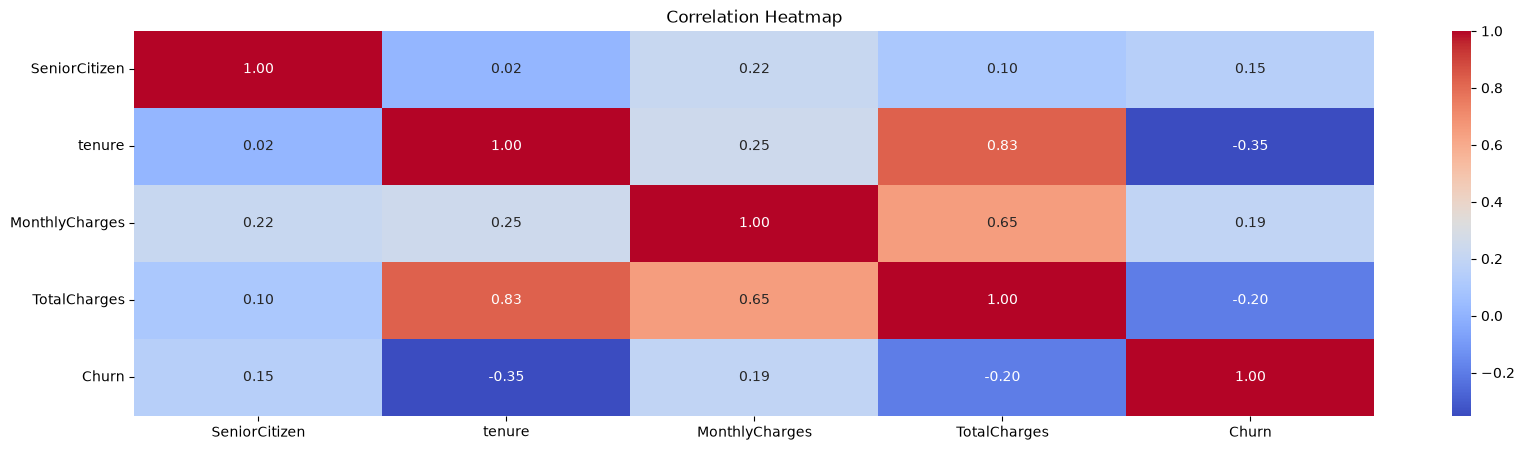

In [48]:
plt.figure(figsize=(20, 5))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


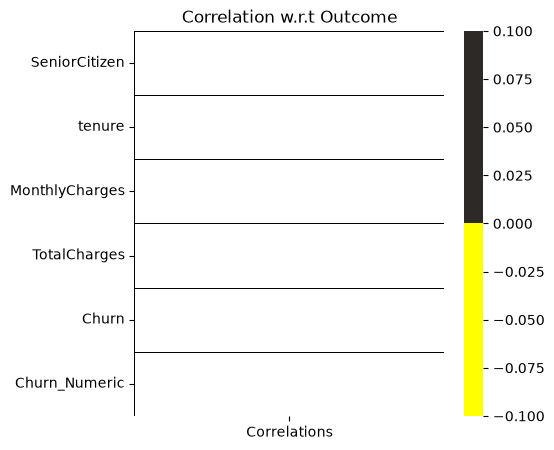

In [49]:
# Convert Churn from Yes/No to 1/0
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Calculate correlation for numeric columns only
corr = df.corrwith(df['Churn_Numeric'], numeric_only=True).sort_values(ascending=False).to_frame()
corr.columns = ['Correlations']

# Plot the heatmap
plt.subplots(figsize=(5, 5))
sns.heatmap(corr, annot=True, cmap=colors, linewidths=0.4, linecolor='black')
plt.title('Correlation w.r.t Outcome')
plt.show()

## Feature selection

In [50]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df = df.copy(deep = True)
text_data_features = [i for i in list(df.columns) if i not in list(df.describe().columns)]

print('Label Encoder Transformation')
for i in text_data_features :
    df[i] = le.fit_transform(df[i])
    print(i,' : ',df[i].unique(),' = ',le.inverse_transform(df[i].unique()))

Label Encoder Transformation
gender  :  [0 1]  =  ['Female' 'Male']
Partner  :  [1 0]  =  ['Yes' 'No']
Dependents  :  [0 1]  =  ['No' 'Yes']
PhoneService  :  [0 1]  =  ['No' 'Yes']
MultipleLines  :  [1 0 2]  =  ['No phone service' 'No' 'Yes']
InternetService  :  [0 1 2]  =  ['DSL' 'Fiber optic' 'No']
OnlineSecurity  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
OnlineBackup  :  [2 0 1]  =  ['Yes' 'No' 'No internet service']
DeviceProtection  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
TechSupport  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
StreamingTV  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
StreamingMovies  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
Contract  :  [0 1 2]  =  ['Month-to-month' 'One year' 'Two year']
PaperlessBilling  :  [1 0]  =  ['Yes' 'No']
PaymentMethod  :  [2 3 0 1]  =  ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [51]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Numeric
0,0,0,1,0,0.013889,0,1,0,0,2,...,0,0,0,0,1,2,0.115423,0.003437,0,NaN
1,1,0,0,0,0.472222,1,0,0,2,0,...,0,0,0,1,0,3,0.385075,0.217564,0,NaN
2,1,0,0,0,0.027778,1,0,0,2,2,...,0,0,0,0,1,3,0.354229,0.012453,1,NaN
3,1,0,0,0,0.625000,0,1,0,2,0,...,2,0,0,1,0,0,0.239303,0.211951,0,NaN
4,0,0,0,0,0.027778,1,0,1,0,0,...,0,0,0,0,1,2,0.521891,0.017462,1,NaN


In [52]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2,mutual_info_classif

In [53]:
df.loc[:,cat_cols]

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,0,0,1,0,0,1,0,0,2,0,0,0,0,0,1,2,0
1,1,0,0,0,1,0,0,2,0,2,0,0,0,1,0,3,0
2,1,0,0,0,1,0,0,2,2,0,0,0,0,0,1,3,1
3,1,0,0,0,0,1,0,2,0,2,2,0,0,1,0,0,0
4,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,1,2,0,2,0,2,2,2,2,1,1,3,0
7039,0,0,1,1,1,2,1,0,2,2,0,2,2,1,1,1,0
7040,0,0,1,1,0,1,0,2,0,0,0,0,0,0,1,2,0
7041,1,1,1,0,1,2,1,0,0,0,0,0,0,0,1,3,1


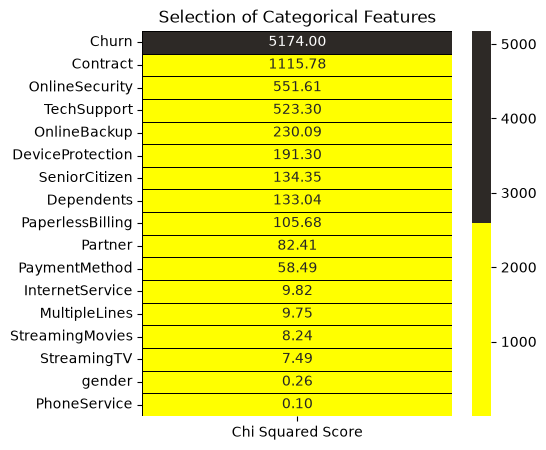

In [54]:
features = df.loc[:,cat_cols]
target = df.loc[:,'Churn']

best_features = SelectKBest(score_func = chi2,k = 'all')
fit = best_features.fit(features,target)

featureScores = pd.DataFrame(data = fit.scores_,index = list(features.columns),columns = ['Chi Squared Score']) 

plt.subplots(figsize = (5,5))
sns.heatmap(featureScores.sort_values(ascending = False,by = 'Chi Squared Score'),annot = True,cmap = colors,linewidths = 0.4,linecolor = 'black',fmt = '.2f');
plt.title('Selection of Categorical Features');

PhoneService, Gender, StreamingTV, StreamingMovies, MultipleLines, and InternetService show a very low correlation with Churn.

## Features selection for numerical features

In [55]:
from sklearn.feature_selection import f_classif

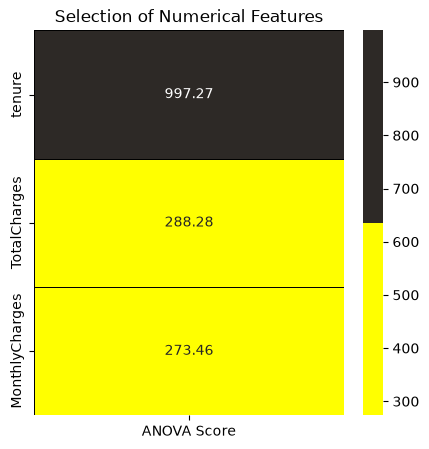

In [56]:
features = df.loc[:,num_cols]
target = df.loc[:,'Churn']

best_features = SelectKBest(score_func = f_classif,k = 'all')
fit = best_features.fit(features,target)

featureScores = pd.DataFrame(data = fit.scores_,index = list(features.columns),columns = ['ANOVA Score']) 

plt.subplots(figsize = (5,5))
sns.heatmap(featureScores.sort_values(ascending = False,by = 'ANOVA Score'),annot = True,cmap = colors,linewidths = 0.4,linecolor = 'black',fmt = '.2f');
plt.title('Selection of Numerical Features');

## Comments
According to the ANOVA test, the higher the ANOVA score, the greater the importance of the feature.

Based on the results above, we need to include all numerical features for modeling.

In [57]:
df.drop(columns = ['PhoneService', 'gender','StreamingTV','StreamingMovies','MultipleLines','InternetService'],inplace = True)
df.head()

,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Numeric
0,0,1,0,0.013889,0,2,0,0,0,1,2,0.115423,0.003437,0,NaN
1,0,0,0,0.472222,2,0,2,0,1,0,3,0.385075,0.217564,0,NaN
2,0,0,0,0.027778,2,2,0,0,0,1,3,0.354229,0.012453,1,NaN
3,0,0,0,0.625000,2,0,2,2,1,0,0,0.239303,0.211951,0,NaN
4,0,0,0,0.027778,0,0,0,0,0,1,2,0.521891,0.017462,1,NaN


## Balancing

here are two options for dealing with imbalanced data:

Undersampling: Trim the majority class samples of the target variable.

Oversampling: Increase the minority class samples of the target variable to match the majority class.

After experimenting with both undersampling and oversampling, we decided on oversampling!

I will use `imblearn` for data balancing. pip statement: `pip install imbalanced-learn`

In [58]:
import imblearn
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

In [59]:
over = SMOTE(sampling_strategy = 1)

f1 = df.iloc[:,:13].values
t1 = df.iloc[:,13].values

f1, t1 = over.fit_resample(f1, t1)
Counter(t1)

Counter({np.int64(0): 5174, np.int64(1): 5174})

## Modelling

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import precision_recall_curve

In [61]:
x_train, x_test, y_train, y_test = train_test_split(f1, t1, test_size = 0.20, random_state = 2)

In [62]:
def model(classifier,x_train,y_train,x_test,y_test):
    
    classifier.fit(x_train,y_train)
    prediction = classifier.predict(x_test)
    cv = RepeatedStratifiedKFold(n_splits = 10,n_repeats = 3,random_state = 1)
    print("Cross Validation Score : ",'{0:.2%}'.format(cross_val_score(classifier,x_train,y_train,cv = cv,scoring = 'roc_auc').mean()))
    print("ROC_AUC Score : ",'{0:.2%}'.format(roc_auc_score(y_test,prediction)))
    plt.show()

def model_evaluation(classifier,x_test,y_test):
    
    # Confusion Matrix
    cm = confusion_matrix(y_test,classifier.predict(x_test))
    names = ['True Neg','False Pos','False Neg','True Pos']
    counts = [value for value in cm.flatten()]
    percentages = ['{0:.2%}'.format(value) for value in cm.flatten()/np.sum(cm)]
    labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(names,counts,percentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cm,annot = labels,cmap = 'Blues',fmt ='')
    
    # Classification Report
    print(classification_report(y_test,classifier.predict(x_test)))

## 1) X-GB Classifier

In [63]:
from xgboost import XGBClassifier

classifier_xgb = XGBClassifier(learning_rate= 0.01,max_depth = 3,n_estimators = 1000)

In [64]:
model(classifier_xgb,x_train,y_train,x_test,y_test)

Cross Validation Score :  90.42%
ROC_AUC Score :  83.21%


              precision    recall  f1-score   support

           0       0.86      0.79      0.83      1040
           1       0.80      0.87      0.84      1030

    accuracy                           0.83      2070
   macro avg       0.83      0.83      0.83      2070
weighted avg       0.83      0.83      0.83      2070



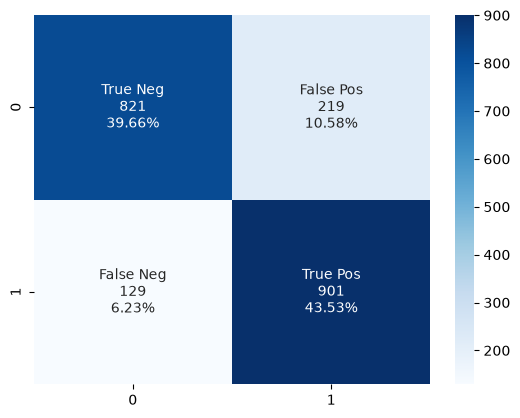

In [65]:
model_evaluation(classifier_xgb,x_test,y_test)

## 2 lgbm classifier

In [66]:
from lightgbm import LGBMClassifier

classifier_lgbm = LGBMClassifier(learning_rate= 0.01,max_depth = 3,n_estimators = 1000, force_col_wise='true',verbose=-1)

In [67]:
model(classifier_lgbm,x_train,y_train,x_test,y_test)


C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-pack

Cross Validation Score :  90.49%
ROC_AUC Score :  83.02%


C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1040
           1       0.80      0.87      0.84      1030

    accuracy                           0.83      2070
   macro avg       0.83      0.83      0.83      2070
weighted avg       0.83      0.83      0.83      2070



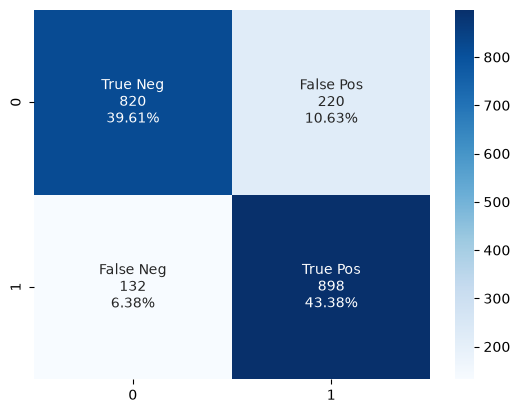

In [68]:
model_evaluation(classifier_lgbm,x_test,y_test)

## Random Forest Classifier

In [69]:
from sklearn.ensemble import RandomForestClassifier
classifier_rf = RandomForestClassifier(max_depth = 4,random_state = 0)

In [70]:
model(classifier_rf,x_train,y_train,x_test,y_test)

Cross Validation Score :  85.46%
ROC_AUC Score :  78.05%


              precision    recall  f1-score   support

           0       0.82      0.72      0.77      1040
           1       0.75      0.84      0.79      1030

    accuracy                           0.78      2070
   macro avg       0.78      0.78      0.78      2070
weighted avg       0.78      0.78      0.78      2070



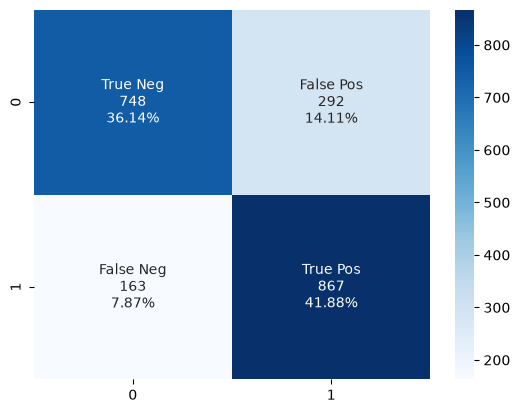

In [71]:
model_evaluation(classifier_rf,x_test,y_test)

## Decison tree Classifier

In [72]:
from sklearn.tree import DecisionTreeClassifier
classifier_dt = DecisionTreeClassifier(random_state = 1000,max_depth = 4,min_samples_leaf = 1)

In [73]:
model(classifier_dt,x_train,y_train,x_test,y_test)

Cross Validation Score :  84.39%
ROC_AUC Score :  77.74%


              precision    recall  f1-score   support

           0       0.79      0.77      0.78      1040
           1       0.77      0.79      0.78      1030

    accuracy                           0.78      2070
   macro avg       0.78      0.78      0.78      2070
weighted avg       0.78      0.78      0.78      2070



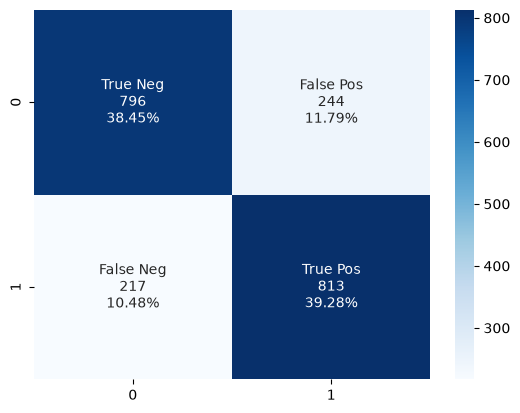

In [74]:
model_evaluation(classifier_dt,x_test,y_test)

## 5) Stack of XGBClassifier, LightGBMClassifier, Random Forest Classifer & Decision Tree Classifier

In [75]:
from sklearn.ensemble import StackingClassifier


stack = StackingClassifier(estimators = [('classifier_xgb',classifier_xgb),
                                         ('classifier_lgbm',classifier_lgbm),
                                         ('classifier_rf',classifier_rf),
                                         ('classifier_dt',classifier_dt)],
                           final_estimator = classifier_lgbm)

In [76]:
stack.fit(x_train, y_train)

C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-pack

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('classifier_xgb', ...), ('classifier_lgbm', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.","LGBMClassifie...0, verbose=-1)"
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[XGBClassifier...ree=None, ...), LGBMClassifie...0, verbose=-1), RandomForestC...andom_state=0), DecisionTreeC...om_state=1000)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlyin

In [77]:
import joblib
joblib.dump(stack, "telecom_churn_stack.pkl")

['telecom_churn_stack.pkl']

C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\OneDrive\Desktop\Consumer_churn_prediction\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1040
           1       0.81      0.87      0.84      1030

    accuracy                           0.84      2070
   macro avg       0.84      0.84      0.84      2070
weighted avg       0.84      0.84      0.84      2070



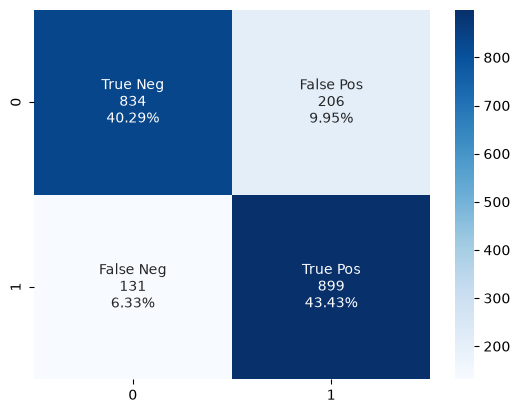

In [78]:
model_evaluation(stack, x_test, y_test)

## Summary
Three customer segments should be targeted: Senior Citizens, those living with a partner, and those living alone.

While the number of Senior Citizen customers is lower, their minimum monthly charges are higher compared to other segments; they are willing to pay a premium but require a corresponding level of service. Customers living with a partner or alone tend to prefer services with monthly charges below 65.

Since the initial six-month tenure is the most critical and uncertain period for customers, comprehensive focus should be placed on Online Security, Online Backup, Device Protection, and Tech Support. Churn rates for these services need to be reduced!

After establishing a robust support system, the company should increase the adoption of Multiple Lines for phone services and Fiber Optic cables for internet services. However, the primary obstacle for these two services is the 75+ monthly charge threshold.

Therefore, they should create service combinations—specifically "No Multiple Lines + Fiber Optic" and "Multiple Lines + DSL"—that result in an average monthly charge in the 100–120 range.

This strategy will increase average revenue per user by eliminating the "No Multiple Lines + DSL" option, which typically carries a lower monthly charge of 60–70!

Streaming TV and Streaming Movies services need to be made more affordable while also shortening the service duration. The content for these services should appeal to all customer segments. These offerings must be supported by an easy and seamless payment method. Due to high churn rates, the use of electronic checks for payments needs to be discontinued in favor of a complete focus on automated bank transfers and automated credit card payments! However, for these two payment methods, the average tenure before churn occurs would need to exceed 20 months—double the lifespan associated with electronic checks.

While the entry-level cost for electronic checks is around 60, the cost for automated bank transfers and automated credit card payments is around 20. Paperless billing is another costly feature, starting at 60, whereas the other options are inexpensive, starting at 20.